# DATA ANALYSIS PROJECT

# 🛒 Retail Sales Data Analysis Project

## 📌 Project Objective

This project demonstrates an end-to-end retail data analysis workflow, beginning with raw transactional data and progressing through data auditing, cleaning, validation, exploratory data analysis (EDA), and business insights.

## Goals

- Understand the dataset
- Identify data quality issues
- Handle missing values
- Validate business rules
- Perform exploratory data analysis
- Generate business recommendations

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

# 📑 Notebook Roadmap

## Import Libraries
- Load Dataset
- Dataset Overview
- Data Description
- Data Audit
- Missing Value Analysis
- Data Cleaning
- Data Validation
- Feature Engineering
- Exploratory Data Analysis
- Business Insights
- Recommendations
- Conclusion

In [320]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [321]:
df = pd.read_csv("retail_sales_clean.csv")
print(f"Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 1,987
Columns: 13


### DATA VALIDATION AND EXPLICIT TEST

In [322]:
# INITAL INSPECTION OF DATA
from IPython.display import display
def inspection(df):
    print('Dataset Exploration Dashboard')
    print("=" * 40)

    #1 High level Summary table
    summary_data =  {
        "Metric":['Total_Rows','Total_Columns','Duplicated_Rows','Total_Missing_Values',"Memory_Usage"],
        "Values":[
            f'{df.shape[0]:}',
            f'{df.shape[1]:}',
            f'{df.duplicated().sum():}',
            f'{df.isnull().sum().sum():}',
            f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
        ]
    }
    display(pd.DataFrame(summary_data).style.hide(axis='index').set_properties(**{
        'text-align':'left',
        'font-weight':'bold'
    }))
    print("="*40)
    #COLORED INFO TABLE
    print("COLUMN METDATA & MEMORY")

    info_df= pd.DataFrame(
        {
             "Column": df.columns,
    "Type": df.dtypes.values,
    "NON-Null-Count": df.notnull().sum().values,
    "NULL-Count": df.isna().sum().values,
    "Null %": (df.isna().sum().values / len(df) * 100).round(2),
    "Unique Values": df.nunique().values
        }
    )

    #Styling Table
    styled_info = (
    info_df.style
    .background_gradient(subset=["Null %"], cmap="Reds")
    .background_gradient(subset=["Unique Values"], cmap="Blues")
    .background_gradient(subset=["NULL-Count"], cmap="Greens")    
    .format({"Null %": "{:.2f}%"})
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#4b4b4b"),
                ("color", "white"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center")
            ]
        }
    ])
)

    display(styled_info)
    
inspection(df)
    

Dataset Exploration Dashboard


Metric,Values
Total_Rows,1987
Total_Columns,13
Duplicated_Rows,0
Total_Missing_Values,0
Memory_Usage,0.77 MB


COLUMN METDATA & MEMORY


,Column,Type,NON-Null-Count,NULL-Count,Null %,Unique Values
0,transactions_id,int64,1987,0,0.00%,1987
1,sale_date,object,1987,0,0.00%,644
2,sale_time,object,1987,0,0.00%,763
3,customer_id,int64,1987,0,0.00%,155
4,gender,object,1987,0,0.00%,2
5,age,float64,1987,0,0.00%,47
6,category,object,1987,0,0.00%,3
7,quantity,float64,1987,0,0.00%,4
8,price_per_unit,float64,1987,0,0.00%,5
9,cogs,float64,1987,0,0.00%,276


In [323]:

df["sale_date"] = pd.to_datetime(df["sale_date"])

df["sale_time"] = pd.to_datetime(
    df["sale_time"]
).dt.time
print(df[["sale_date", "sale_time"]].head())

   sale_date sale_time
0 2022-11-05  10:47:00
1 2022-07-09  11:00:00
2 2022-12-12  10:48:00
3 2022-01-06  08:53:00
4 2022-11-14  08:35:00


### FINANCIAL METRICS


In [324]:
#gross profit = revenue-cogs
#total_revenue= sum of total sale
#unit_sold= sum of total quantity
#transaction= total unique transaction_id
#average_selling_price= revenue/unitsold

In [325]:
df.head()

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantity,price_per_unit,cogs,total_sale,Month,Day
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0,November,Saturday
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0,July,Saturday
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0,December,Monday
3,1180,2022-01-06,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0,January,Thursday
4,1522,2022-11-14,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0,November,Monday


In [326]:
total_revenue = df['total_sale'].sum().round(2)
units_sold = df['quantity'].sum()
transaction = df['transactions_id'].nunique()
average_selling_price = total_revenue / units_sold
aov = total_revenue / transaction
units_per_transaction = units_sold / transaction

# Create the metrics DataFrame
revenue_metrics = pd.DataFrame({
    "Metric": [
        "Revenue",
        "Units Sold",
        "Transactions",
        "Average Selling Price",
        "Average Order Value",
        "Units per Transaction"
    ],
    "Value": [
        round(total_revenue, 2),
        round(units_sold, 2),
        round(transaction, 2),
        round(average_selling_price, 2),
        round(aov, 2),
        round(units_per_transaction, 2)
    ]
})

display(revenue_metrics)

,Metric,Value
0,Revenue,908230.00
1,Units Sold,4995.00
2,Transactions,1987.00
3,Average Selling Price,181.83
4,Average Order Value,457.09
5,Units per Transaction,2.51


In [327]:
# #LEVEL 2 COST METRICS
# total_cogs=df['cogs'].sum()
# cogs_per_unit=total_cogs / units_sold
# cogs_ratio=total_cogs / total_revenue
# #Profit Metrics
# gross_profit = df["gross_profit"].sum()
# gross_margin_pct = gross_profit / total_revenue
# gross_profit_per_unit = gross_profit / units_sold
# gross_profit_per_transaction = (
#     gross_profit / transaction
# )
# df["gross_margin_pct"] = (
#     df["gross_profit"] /
#     df["total_sale"]
# )


In [328]:
#LEVEL 3 CUSTOMER METRIC
customers = df["customer_id"].nunique()
revenue_per_customer = total_revenue / customers

gross_profit_per_customer = (
    gross_profit / customers
)

transactions_per_customer = (
    transaction / customers
)



In [329]:
# ROW-LEVEL FINANCIAL METRICS

df["revenue"] = df["total_sale"]

df["cogs"] = df["cogs"]

df["gross_profit"] = (
    df["revenue"] - df["cogs"]
)

df["gross_margin_pct"] = (
    df["gross_profit"] /
    df["revenue"]
)

df["revenue_per_unit"] = (
    df["revenue"] /
    df["quantity"]
)

df["cogs_per_unit"] = (
    df["cogs"] /
    df["quantity"]
)

df["gross_profit_per_unit"] = (
    df["gross_profit"] /
    df["quantity"]
)

# DEEP ANALYSIS 
#### ANALYTICAL DATASET

The cleaned dataframe below is treated as the analytical source 
of truth.

All business metrics, customer analysis, profitability analysis,
and dashboard outputs will be derived from this dataset.

In [330]:
#dedicated dataframe keeping original safe
df_gold=df.copy()
print("Analytical dataset created")
print(f"Rows: {df_gold.shape[0]:,}")
print(f"Columns: {df_gold.shape[1]:,}")

Analytical dataset created
Rows: 1,987
Columns: 19


### INSIGHT 1
Data Retention Rate
Data retention rate measures how much of the original dataset
remains usable after data cleaning.

A high retention rate indicates that cleaning removed relatively
few records while preserving most of the original information.

In [331]:
#DATA RETENTION RATE
raw_rows=2000
clean_rows=len(df_gold)
rows_removed=raw_rows-clean_rows
retention_rate = (clean_rows / raw_rows) * 100
removal_rate = (rows_removed / raw_rows) * 100

retention_summary = pd.DataFrame({
    "Metric": [
        "Raw Records",
        "Clean Records",
        "Records Removed",
        "Retention Rate",
        "Removal Rate"
    ],
    "Value": [
        raw_rows,
        clean_rows,
        rows_removed,
        f"{retention_rate:.2f}%",
        f"{removal_rate:.2f}%"
    ]
})

display(retention_summary)

,Metric,Value
0,Raw Records,2000
1,Clean Records,1987
2,Records Removed,13
3,Retention Rate,99.35%
4,Removal Rate,0.65%


#### Business Interpretation

The cleaning pipeline retained 99.35% of the original transaction
records and removed 0.65%.

This indicates that the dataset experienced relatively limited
record-level data loss during cleaning. The high retention rate
supports using the cleaned dataset for downstream analysis.

### INSIGHT 2 — Transaction ID / Primary-Key Integrity

In [332]:
# INITAL INSPECTION OF DATA
from IPython.display import display
def inspection(df):
    print('Dataset Exploration Dashboard')
    print("=" * 40)

    #1 High level Summary table
    summary_data =  {
        "Metric":['Total_Rows','Total_Columns','Duplicated_Rows','Total_Missing_Values',"Memory_Usage"],
        "Values":[
            f'{df.shape[0]:}',
            f'{df.shape[1]:}',
            f'{df.duplicated().sum():}',
            f'{df.isnull().sum().sum():}',
            f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
        ]
    }
    display(pd.DataFrame(summary_data).style.hide(axis='index').set_properties(**{
        'text-align':'left',
        'font-weight':'bold'
    }))
    print("="*40)
    #COLORED INFO TABLE
    print("COLUMN METDATA & MEMORY")

    info_df= pd.DataFrame(
        {
             "Column": df.columns,
    "Type": df.dtypes.values,
    "NON-Null-Count": df.notnull().sum().values,
    "NULL-Count": df.isna().sum().values,
    "Null %": (df.isna().sum().values / len(df) * 100).round(2),
    "Unique Values": df.nunique().values
        }
    )

    #Styling Table
    styled_info = (
    info_df.style
    .background_gradient(subset=["Null %"], cmap="Reds")
    .background_gradient(subset=["Unique Values"], cmap="Blues")
    .background_gradient(subset=["NULL-Count"], cmap="Greens")    
    .format({"Null %": "{:.2f}%"})
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#4b4b4b"),
                ("color", "white"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center")
            ]
        }
    ])
)

    display(styled_info)
    
inspection(df)
    

Dataset Exploration Dashboard


Metric,Values
Total_Rows,1987
Total_Columns,19
Duplicated_Rows,0
Total_Missing_Values,0
Memory_Usage,0.73 MB


COLUMN METDATA & MEMORY


,Column,Type,NON-Null-Count,NULL-Count,Null %,Unique Values
0,transactions_id,int64,1987,0,0.00%,1987
1,sale_date,datetime64[ns],1987,0,0.00%,644
2,sale_time,object,1987,0,0.00%,763
3,customer_id,int64,1987,0,0.00%,155
4,gender,object,1987,0,0.00%,2
5,age,float64,1987,0,0.00%,47
6,category,object,1987,0,0.00%,3
7,quantity,float64,1987,0,0.00%,4
8,price_per_unit,float64,1987,0,0.00%,5
9,cogs,float64,1987,0,0.00%,276


#### BUSINESS INTERPRETATION
Each retained transaction is uniquely identified by transactions_id, so the transaction-level dataset has a valid primary-key structure for downstream aggregation.

### INSIGHT 3 BUSINESS RULE VALIDATION



In [333]:
business_rules = {}
#quantity must be positive
business_rules["Quantity > 0"] = (
    df["quantity"] > 0
)
#price must be positive
business_rules['PRICE >0'] =(
    df['price_per_unit'] >0
)
#cogs cannot be negative
business_rules["COGS >= 0"] = (
    df["cogs"] >= 0
)
#sales cannot be negative
business_rules["Total Sale >= 0"] = (
    df["total_sale"] >= 0
)
#EXPECTED
df["expected_total_sale"] = (
    df["quantity"] *
    df["price_per_unit"]
)

#CALCULATE DIFFERENCE
df["sales_difference"] = (
    df["total_sale"] -
    df["expected_total_sale"]
)

In [334]:
business_rule_results = pd.DataFrame({
    "Business Rule": business_rules.keys(),
    "Valid": [
        rule.all()
        for rule in business_rules.values()
    ],
    "Invalid Records": [
        (~rule).sum()
        for rule in business_rules.values()
    ]
})

display(business_rule_results)

,Business Rule,Valid,Invalid Records
0,Quantity > 0,True,0
1,PRICE >0,True,0
2,COGS >= 0,True,0
3,Total Sale >= 0,True,0


#### BUSINESS INTERPRETAION
The cleaned transaction dataset passes all defined business-rule
checks.

Each transaction contains a positive quantity and selling price,
non-negative COGS and sales values, and the reported sales amount
is mathematically consistent with quantity multiplied by
price per unit.

### INSIGHT 4 Total Revenue
total sales revenue did the business generate during the analysis period

In [335]:
revenue = df["total_sale"].sum()
calculated_revenue = (
    df["quantity"] *
    df["price_per_unit"]
).sum()
#VALIDATE
revenue_difference = (
    revenue - calculated_revenue
)
#TIME PERIOD CONTEXT
analysis_start = df["sale_date"].min()
analysis_end = df["sale_date"].max()
print(f"Analysis Period: {analysis_start.date()} → {analysis_end.date()}")

#REVENUE PER DAY
calendar_days = (
    analysis_end - analysis_start
).days + 1

average_daily_revenue = (
    revenue / calendar_days
)
print(
    f"Average Revenue per Calendar Day: "
    f"{average_daily_revenue:,.2f}"
)
#INSIGHT TABLE 
revenue_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Analysis Start",
        "Analysis End",
        "Calendar Days",
        "Average Revenue per Calendar Day"
    ],
    "Value": [
        f"${revenue:,.2f}",
        analysis_start.date(),
        analysis_end.date(),
        calendar_days,
        f"${average_daily_revenue:,.2f}"
    ]
})

display(revenue_summary)


Analysis Period: 2022-01-01 → 2023-12-31
Average Revenue per Calendar Day: 1,244.15


,Metric,Value
0,Total Revenue,"$908,230.00"
1,Analysis Start,2022-01-01
2,Analysis End,2023-12-31
3,Calendar Days,730
4,Average Revenue per Calendar Day,"$1,244.15"


#### BUSINESS INTERPRETAION
The business generated the calculated total revenue across the
observed transaction period.
Because this dataset represents a fixed historical observation
period, total revenue should not be interpreted as annual revenue
unless the analysis period covers a full year.

### INSIGHT 5 Total Units Sold
total units solddid the business generate during the analysis period

In [336]:
units_sold_insight = pd.DataFrame({
    "Metric": [
        "Total Units Sold",
        "Units per Transaction",
        "Average Selling Price"
    ],
    "Value": [
        units_sold,
        units_per_transaction,
        average_selling_price
    ]
})

display(units_sold_insight)

,Metric,Value
0,Total Units Sold,4995.000000
1,Units per Transaction,2.513840
2,Average Selling Price,181.827828


#### Business Interpretation

Total units sold represents the physical sales volume generated
during the analysis period.

Units per transaction measures the average number of products
purchased in each transaction, providing an indication of basket
size.

Average selling price connects physical sales volume with revenue
and will be useful later when decomposing revenue into volume and
pricing effects.

### INSIGHT 6 TRANSACTION VOLUME
transaction activity does the business generate, and how important is transaction frequency to the revenue engine

In [337]:
transaction_volume_insight = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Transactions per Customer",
        "Average Order Value",
        "Units per Transaction"
    ],
    "Value": [
        transaction,
        round(transactions_per_customer, 2),
        round(aov, 2),
        round(units_per_transaction, 2)
    ]
})

display(transaction_volume_insight)

,Metric,Value
0,Total Transactions,1987.00
1,Transactions per Customer,12.82
2,Average Order Value,457.09
3,Units per Transaction,2.51


In [338]:
# total transactions generated by each customer:
customer_transaction_counts= df.groupby('customer_id')['transactions_id'].nunique().sort_values(ascending=True)
top_10_customers = (
    df.groupby("customer_id")
      .agg(
          transactions=("transactions_id", "nunique"),
          total_spend=("total_sale", "sum"),
          units_purchased=("quantity", "sum")
      )
      .sort_values(
          by="total_spend",
          ascending=False
      )
      .head(10)
      .reset_index()
)
top_10_customers
display(top_10_customers)

,customer_id,transactions,total_spend,units_purchased
0,3,76,38440.0,201.0
1,1,76,30750.0,186.0
2,5,63,30405.0,159.0
3,2,69,25295.0,154.0
4,4,73,23580.0,164.0
5,87,25,15855.0,67.0
6,54,21,13475.0,58.0
7,71,19,12790.0,52.0
8,55,17,12080.0,41.0
9,84,18,11730.0,47.0


#### Business Interpretation

Transaction volume represents the frequency of purchasing events
within the observed dataset.

These relationships will be used later to distinguish revenue
growth driven by transaction frequency from revenue growth driven
by basket value.

### INSIGHT 7 AVERAGE ORDER VALUE
revenue does the business generate per transaction, and what is driving the size of each order

In [339]:
aov_insight = pd.DataFrame({
    "Metric": [
        "Average Order Value",
        "Average Selling Price",
        "Units per Transaction",
        "Revenue per Customer"
    ],
    "Value": [
        round(aov, 2),
        round(average_selling_price, 2),
        round(units_per_transaction, 2),
        round(revenue_per_customer, 2)
    ]
})

display(aov_insight)

,Metric,Value
0,Average Order Value,457.09
1,Average Selling Price,181.83
2,Units per Transaction,2.51
3,Revenue per Customer,5859.55


In [340]:
#customer level aov == largest transaction per purchase
customer_aov=df.groupby('customer_id').agg(
            revenue=('total_sale','sum'),
            transaction=('transactions_id','nunique')
)
customer_aov["aov"] = (
    customer_aov["revenue"] /
    customer_aov['transaction']
)

display(
    customer_aov
    .sort_values("aov", ascending=False)
    .head(10)
    .reset_index()
)

,customer_id,revenue,transaction,aov
0,34,4100.0,3,1366.666667
1,142,5960.0,5,1192.000000
2,11,5700.0,5,1140.000000
3,45,3300.0,3,1100.000000
4,36,2990.0,3,996.666667
5,67,9225.0,10,922.500000
6,29,8455.0,10,845.500000
7,83,9160.0,11,832.727273
8,130,7435.0,9,826.111111
9,65,9320.0,12,776.666667


#### Business Interpretation
Average Order Value measures the average revenue generated per
transaction and represents a core measure of basket economics
Customer-level AOV also reveals differences in purchasing behavior
that can be hidden by the overall company average.

### INSIGHT 8 GROSS PROFIT
gross profit generated after accounting for the cost of goods sold

In [341]:
#insight table
gross_profit_insight = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total COGS",
        "Gross Profit",
        "Gross Margin",
        "Gross Profit per Unit",
        "Gross Profit per Transaction"
    ],
    "Value": [
        round(total_revenue, 2),
        round(total_cogs, 2),
        round(gross_profit, 2),
        f"{gross_margin_pct:.2%}",
        round(gross_profit_per_unit, 2),
        round(gross_profit_per_transaction, 2)
    ]
})

display(gross_profit_insight)

,Metric,Value
0,Total Revenue,908230.0
1,Total COGS,188927.8
2,Gross Profit,908230.0
3,Gross Margin,100.00%
4,Gross Profit per Unit,181.83
5,Gross Profit per Transaction,457.09


In [342]:
#profit bridge new
profit_bridge = pd.DataFrame({
    "Metric": [
        "Revenue",
        "COGS",
        "Gross Profit"
    ],
    "Value": [
        total_revenue,
        total_cogs,
        gross_profit
    ]
})

display(profit_bridge)

,Metric,Value
0,Revenue,908230.0
1,COGS,188927.8
2,Gross Profit,908230.0


#### Business Interpretation
Gross profit represents the value remaining after deducting the
cost of goods sold from revenue.
Gross profit per unit and gross profit per transaction provide
additional views of profitability at the product-volume and
transaction levels.


### INSIGHT 9 REVENUE BY CATEGORY
Which product categories generate the most revenue, and how important is each category to the overall business


In [343]:
category_revenue=df.groupby('category').agg(
    revenue=('revenue','sum'),
    units_sold=('quantity','sum'),
    transaction=('transactions_id','nunique')
).sort_values('revenue',ascending=False).reset_index()
category_revenue

,category,revenue,units_sold,transaction
0,Electronics,311445.0,1682.0,678
1,Clothing,309995.0,1780.0,698
2,Beauty,286790.0,1533.0,611


In [344]:
# #revenue contribution
# category_revenue_display = category_revenue.copy()

# category_revenue_display["revenue"] = (
#     category_revenue_display["revenue"]
#     .round(2)
# )

# category_revenue_display["revenue_share"] = (
#     category_revenue_display["revenue_share"]
#     .map(lambda x: f"{x:.2%}")
# )

# display(category_revenue_display)

In [345]:
# # revenue related questions
# top_revenue_category=(category_revenue.iloc[0]['category'])
# top_revenue_value = (category_revenue.iloc[0]["revenue"])
# top_revenue_share = (category_revenue.iloc[0]["revenue_share"])
# print(
#     f"Top Revenue Category: {top_revenue_category}"
# )

# print(
#     f"Revenue: ${top_revenue_value:,.2f}"
# )

# print(
#     f"Revenue Share: {top_revenue_share:.2%}"
# )

# category_revenue["units_per_transaction"] = (
#     category_revenue["units_sold"] /
#     category_revenue["transaction"]
# )


# category_revenue["aov"] = (
#     category_revenue["revenue"] /
#     category_revenue["transaction"]
# )

# display(
#     category_revenue[
#         [
#             "category",
#             "revenue",
#             "transaction",
#             "aov",
#             "revenue_share"
#         ]
#     ]
# )


#### Business Interpretation
Category-level revenue analysis identifies which product categories
contribute most to overall sales.
A category with high revenue does not necessarily have the highest
customer demand per transaction or the strongest profitability.
Therefore, revenue contribution should be evaluated alongside
transaction volume, basket value, and ultimately gross profit and
margin.

### INSIGHT 10 Category Gross Profit & Gross Margin
Which categories actually generate the most gross profit, and which categories are the most margin-efficient


In [346]:
category_profibaility=df.groupby('category').agg(
    revenue=("revenue", "sum"),
          cogs=("cogs", "sum"),
          gross_profit=("gross_profit", "sum"),
          units_sold=("quantity", "sum"),
          transactions=("transactions_id", "nunique")
).reset_index()
category_profibaility["gross_margin_pct"] = (
    category_profibaility["gross_profit"] /
    category_profibaility["revenue"]
)
category_profibaility["gross_profit_share"] = (
    category_profibaility["gross_profit"] /
    gross_profit
)
category_profibaility["gross_profit_per_transaction"] = (
    category_profibaility["gross_profit"] /
    category_profibaility["transactions"]
)
category_profitability = (
    category_profibaility
    .sort_values("gross_profit", ascending=False)
    .reset_index(drop=True)
)

display(category_profitability)

,category,revenue,cogs,gross_profit,units_sold,transactions,gross_margin_pct,gross_profit_share,gross_profit_per_transaction
0,Clothing,309995.0,64049.75,245945.25,1780.0,698,0.793385,0.270796,352.357092
1,Electronics,311445.0,66677.45,244767.55,1682.0,678,0.785909,0.269500,361.014086
2,Beauty,286790.0,58200.60,228589.40,1533.0,611,0.797062,0.251687,374.123404


In [347]:
#imp insights from this matrix
top_profit_category=(category_profibaility.iloc[0]['category'])
highest_margin_category = (
    category_profibaility
    .sort_values("gross_margin_pct", ascending=False)
    .iloc[0]
)

# revenue share Vs profit Share
category_profibaility["profit_vs_revenue_share"] = (
    category_profibaility["gross_profit_share"]
    -
    (
        category_profibaility["revenue"]
        / total_revenue
    )
)

#classification 
def classify_profit_contribution(row):
    if row["profit_vs_revenue_share"] > 0.02:
        return "Profit Outperformer"
    elif row["profit_vs_revenue_share"] < -0.02:
        return "Profit Underperformer"
    else:
        return "Balanced"


category_profibaility["profit_position"] = (
    category_profibaility.apply(
        classify_profit_contribution,
        axis=1
    )
)

#### Business Interpretation
Category profitability analysis distinguishes sales scale from
economic contribution.
Comparing revenue share with gross profit share highlights categories
that contribute disproportionately more or less profit than their
sales volume would suggest.

Therefore, the highest-revenue category should not automatically be
considered the most economically attractive category.    

### INSIGHT 11 Category Volume & Basket Behavior
Which categories actually sells the most


In [348]:
category_behavior = category_profibaility[
    [
        "category",
        "revenue",
        "units_sold",
        "transactions"
    ]
].copy()
category_behavior["units_per_transaction"] = (
    category_behavior["units_sold"] /
    category_behavior["transactions"]
)

category_behavior["aov"] = (
    category_behavior["revenue"] /
    category_behavior["transactions"]
)
display(category_behavior)

,category,revenue,units_sold,transactions,units_per_transaction,aov
0,Beauty,286790.0,1533.0,611,2.509002,469.378069
1,Clothing,309995.0,1780.0,698,2.550143,444.118911
2,Electronics,311445.0,1682.0,678,2.480826,459.358407


In [349]:
# CATEGORY WITH LARGEST BASKET
largest_basket_category=(
    category_behavior.sort_values('units_per_transaction',ascending=False).iloc[0]
)
print(
    f"Largest Basket Category: "
    f"{largest_basket_category['category']}"
)

print(
    f"Units per Transaction: "
    f"{largest_basket_category['units_per_transaction']:.2f}"
)
# HIGHEST AOV
highest_aov_category = (
    category_behavior
    .sort_values("aov", ascending=False)
    .iloc[0]
)

print(
    f"Highest AOV Category: "
    f"{highest_aov_category['category']}"
)

print(
    f"AOV: "
    f"${highest_aov_category['aov']:,.2f}"
)

Largest Basket Category: Clothing
Units per Transaction: 2.55
Highest AOV Category: Beauty
AOV: $469.38


#### BUSINESS INTERPRETATION
Here the largest basked category was clothing but highest average order value was beauty , therefore 
Basket Size
    ≠
Basket Value

### INSIGHT 12 Monthly Revenue Trend
revenue change month by month, and which months represent peak or weak business periods


In [350]:
df["year_month"] = df["sale_date"].dt.to_period("M")
# MONTHLY PERFOMANCE YEAR WISE
monthly_performance=df.groupby('year_month').agg(
    revenue=('revenue','sum'),
     transactions=("transactions_id", "nunique"),
          units_sold=("quantity", "sum"),
          gross_profit=("gross_profit", "sum"),
          customers=("customer_id", "nunique")
).reset_index()

monthly_performance["year_month"] = (
    monthly_performance["year_month"].astype(str)
)

display(monthly_performance)

,year_month,revenue,transactions,units_sold,gross_profit,customers
0,2022-01,22635.0,57,144.0,19428.30,49
1,2022-02,16110.0,44,105.0,13111.80,38
2,2022-03,23455.0,45,122.0,20079.00,41
3,2022-04,28535.0,57,146.0,23532.80,45
4,2022-05,24480.0,51,134.0,20713.20,43
5,2022-06,20700.0,43,95.0,17138.95,38
6,2022-07,22195.0,41,92.0,18403.30,39
7,2022-08,21075.0,54,150.0,17948.50,47
8,2022-09,61620.0,127,319.0,47159.15,84
9,2022-10,67735.0,145,386.0,49354.35,87


In [351]:
# MONTHLY AOV AND MARGINS
monthly_performance["aov"] = (
    monthly_performance["revenue"] /
    monthly_performance["transactions"]
)

monthly_performance["gross_margin_pct"] = (
    monthly_performance["gross_profit"] /
    monthly_performance["revenue"]
)

monthly_performance["units_per_transaction"] = (
    monthly_performance["units_sold"] /
    monthly_performance["transactions"]
)

In [352]:
# IMP METRICS
peak_month=(
    monthly_performance.sort_values('revenue',ascending=False).iloc[0]
)
weakest_month = (
    monthly_performance
    .sort_values("revenue")
    .iloc[0]
)

print(
    f"Peak Revenue Month: {peak_month['year_month']} "
    f"(${peak_month['revenue']:,.2f})"
)

print(
    f"Weakest Revenue Month: {weakest_month['year_month']} "
    f"(${weakest_month['revenue']:,.2f})"
)


Peak Revenue Month: 2022-12 ($71,880.00)
Weakest Revenue Month: 2022-02 ($16,110.00)


In [353]:
# PEAK VS WEAK
peak_vs_weak_gap = (
    peak_month["revenue"] -
    weakest_month["revenue"]
)

peak_vs_weak_pct = (
    peak_vs_weak_gap /
    weakest_month["revenue"]
)

print(
    f"Peak vs Weak Revenue Gap: "
    f"${peak_vs_weak_gap:,.2f}"
)

print(
    f"Peak month is "
    f"{peak_vs_weak_pct:.2%} higher than weakest month"
)

Peak vs Weak Revenue Gap: $55,770.00
Peak month is 346.18% higher than weakest month


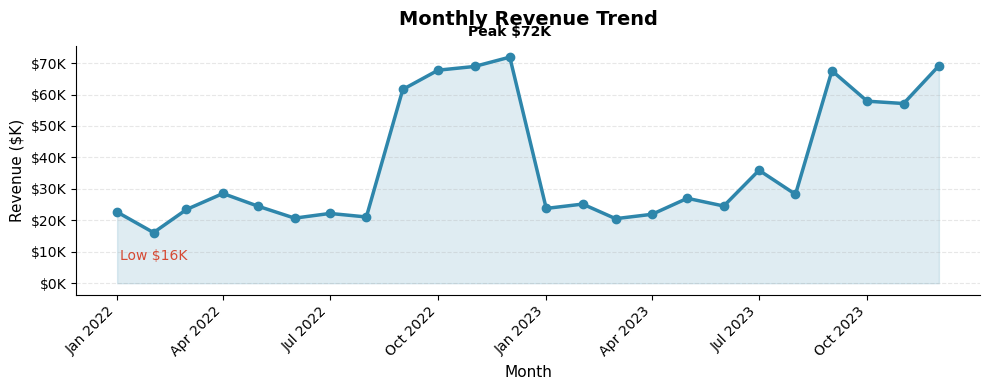

In [354]:
# MONTHLY REVENUE VISUALISATION TREND
monthly_performance["year_month"] = pd.to_datetime(monthly_performance["year_month"])

peak = monthly_performance.loc[monthly_performance["revenue"].idxmax()]
low = monthly_performance.loc[monthly_performance["revenue"].idxmin()]

# Plot
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(monthly_performance["year_month"], monthly_performance["revenue"], 
        color="#2E86AB", linewidth=2.5, marker="o", markersize=6)

ax.fill_between(monthly_performance["year_month"], monthly_performance["revenue"], 
                color="#2E86AB", alpha=0.15)

# Annotations
ax.annotate(f"Peak ${peak['revenue']/1000:.0f}K", 
            xy=(peak["year_month"], peak["revenue"]),
            xytext=(0, 15), textcoords="offset points",
            ha="center", fontweight="bold")

ax.annotate(f"Low ${low['revenue']/1000:.0f}K", 
            xy=(low["year_month"], low["revenue"]),
            xytext=(0, -20), textcoords="offset points",
            ha="center", color="#D64933")

# Labels
ax.set_title("Monthly Revenue Trend", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Revenue ($K)", fontsize=11)
ax.set_xlabel("Month", fontsize=11)

# X-axis - show every 3 months
ax.set_xticks(monthly_performance["year_month"][::3])
ax.set_xticklabels(monthly_performance["year_month"][::3].dt.strftime("%b %Y"), 
                   rotation=45, ha="right")

# Clean styling
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)

# Format y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

plt.tight_layout()
plt.show()

In [355]:
monthly_performance["revenue_share"] = (
    monthly_performance["revenue"] /
    total_revenue
)
display(
    monthly_performance[
        [
            "year_month",
            "revenue",
            "revenue_share"
        ]
    ].sort_values(
        "revenue",
        ascending=False
    ).head().reset_index()
)

,index,year_month,revenue,revenue_share
0,11,2022-12-01,71880.0,0.079143
1,23,2023-12-01,69145.0,0.076132
2,10,2022-11-01,68915.0,0.075878
3,9,2022-10-01,67735.0,0.074579
4,20,2023-09-01,67560.0,0.074386


#### BUSINESS INTERPRETATION
Monthly revenue analysis reveals how sales performance changes
throughout the observed period.

### INSIGHT 13 Month over Month Revenue Growth
What was revenue each month? How did revenue change compared with the previous month?


In [356]:
monthly_growth = monthly_performance.copy()
monthly_growth["year_month"] = pd.to_datetime(monthly_growth["year_month"])

# Format as Jan-2022, Feb-2022, etc.
monthly_growth["month_display"] = monthly_growth["year_month"].dt.strftime("%b-%Y")
# monthly_growth.head(2)
monthly_growth['previous_month_revenue']=(monthly_growth['revenue'].shift(1))
monthly_growth['previous_month_revenue'].head()

# REVENUE CHANGE
monthly_growth["revenue_change"] = (
    monthly_growth["revenue"]
    - monthly_growth["previous_month_revenue"]
)
# IN PERCENTAGE
monthly_growth["revenue_growth_pct"] = (
    monthly_growth["revenue_change"]
    / monthly_growth["previous_month_revenue"]
)
monthly_growth_insight = monthly_growth[
    [
        "year_month",
        "revenue",
        "previous_month_revenue",
        "revenue_change",
        "revenue_growth_pct"
    ]
].copy()

display(monthly_growth_insight.head())

,year_month,revenue,previous_month_revenue,revenue_change,revenue_growth_pct
0,2022-01-01,22635.0,NaN,NaN,NaN
1,2022-02-01,16110.0,22635.0,-6525.0,-0.288270
2,2022-03-01,23455.0,16110.0,7345.0,0.455928
3,2022-04-01,28535.0,23455.0,5080.0,0.216585
4,2022-05-01,24480.0,28535.0,-4055.0,-0.142106


In [357]:
# best month
best_growth_month = (
    monthly_growth
    .dropna(subset=["revenue_growth_pct"])
    .sort_values("revenue_growth_pct", ascending=False)
    .iloc[0]
)
# worst month
worst_growth_month = (
    monthly_growth
    .dropna(subset=["revenue_growth_pct"])
    .sort_values("revenue_growth_pct")
    .iloc[0]
)
# GROWTH MONTHS -- GROWTH,DECLINE,FLAt
growth_months = (
    (monthly_growth["revenue_growth_pct"] > 0)
    .sum()
)

decline_months = (
    (monthly_growth["revenue_growth_pct"] < 0)
    .sum()
)

flat_months = (
    (monthly_growth["revenue_growth_pct"] == 0)
    .sum()
)
print(f"Growth Months:   {growth_months}")
print(f"Decline Months:  {decline_months}")
print(f"Flat Months:     {flat_months}")

Growth Months:   13
Decline Months:  10
Flat Months:     0


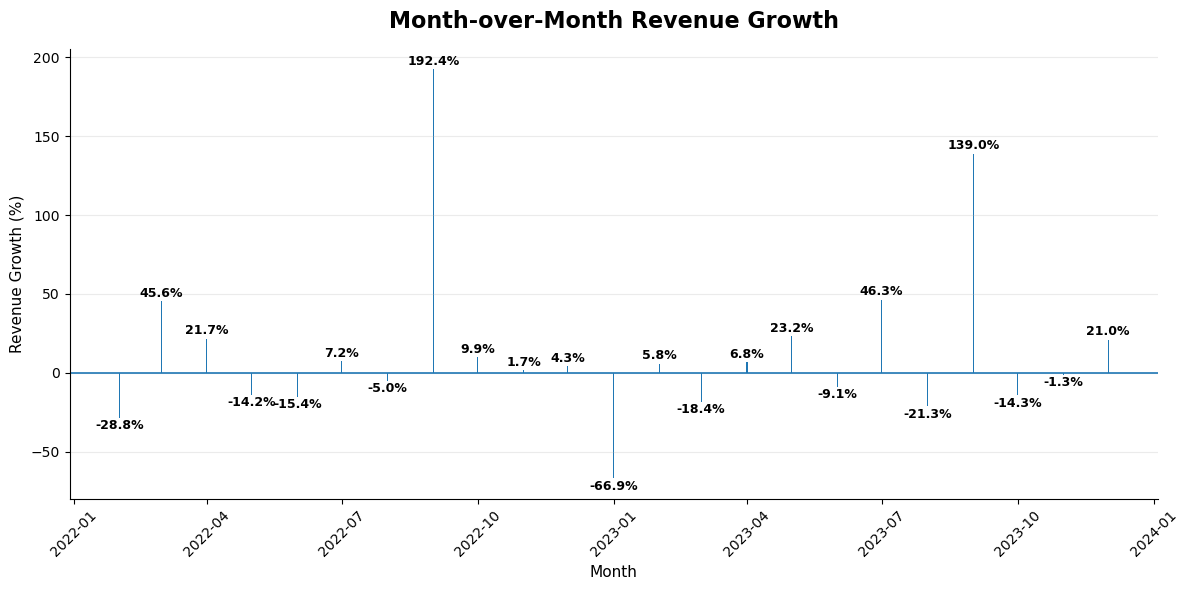

In [358]:
# MONTH OVER MONTH REVENUE GROWTH VISUALIZATION
plot_data = monthly_growth.dropna(
    subset=["revenue_growth_pct"]
).copy()

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    plot_data["year_month"],
    plot_data["revenue_growth_pct"] * 100,
    width=0.7
)

# Zero reference line
ax.axhline(
    0,
    linewidth=1.2
)

# Add labels
for bar, value in zip(
    bars,
    plot_data["revenue_growth_pct"] * 100
):
    if value >= 0:
        y_position = value + 0.8
        va = "bottom"
    else:
        y_position = value - 0.8
        va = "top"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y_position,
        f"{value:.1f}%",
        ha="center",
        va=va,
        fontsize=9,
        fontweight="bold"
    )

ax.set_title(
    "Month-over-Month Revenue Growth",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Revenue Growth (%)", fontsize=11)

ax.tick_params(
    axis="x",
    rotation=45
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [359]:
# ===== CLASSIFICATION FUNCTION =====
def classify_growth(x):
    if pd.isna(x):
        return "No Comparison"
    elif x > 0:
        return "Growth"
    elif x < 0:
        return "Decline"
    else:
        return "Flat"

# ===== APPLY CLASSIFICATION =====
monthly_growth["growth_status"] = (
    monthly_growth["revenue_growth_pct"]
    .apply(classify_growth)
)
monthly_growth["year_month"] = pd.to_datetime(monthly_growth["year_month"])

# Format as Jan-2022, Feb-2022, etc.
monthly_growth["month_display"] = monthly_growth["year_month"].dt.strftime("%b-%Y")
# ===== COLOR MAPPING =====
def color_status(status):
    if status == "Growth":
        return "background-color: #2ECC71; color: white; font-weight: bold"
    elif status == "Decline":
        return "background-color: #E74C3C; color: white; font-weight: bold"
    elif status == "Flat":
        return "background-color: #FFF9C4; color: #333333; font-weight: bold"
    else:
        return "background-color: #F0F0F0; color: #666666"

# ===== STYLING THE DATAFRAME =====
styled_df = monthly_growth[
    [
        "year_month",
        "revenue",
        "revenue_change",
        "revenue_growth_pct",
        "growth_status"
    ]
].style.applymap(color_status, subset=["growth_status"])

# ===== FORMAT NUMBERS =====
styled_df = styled_df.format({
    "revenue": "{:,.2f}",
    "revenue_change": "{:,.2f}",
    "revenue_growth_pct": "{:.1%}"
})

# ===== DISPLAY =====
display(styled_df)

C:\Users\rishu\AppData\Local\Temp\ipykernel_14996\3189874523.py:41: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  ].style.applymap(color_status, subset=["growth_status"])


,year_month,revenue,revenue_change,revenue_growth_pct,growth_status
0,2022-01-01 00:00:00,"22,635.00",nan,nan%,No Comparison
1,2022-02-01 00:00:00,"16,110.00","-6,525.00",-28.8%,Decline
2,2022-03-01 00:00:00,"23,455.00","7,345.00",45.6%,Growth
3,2022-04-01 00:00:00,"28,535.00","5,080.00",21.7%,Growth
4,2022-05-01 00:00:00,"24,480.00","-4,055.00",-14.2%,Decline
5,2022-06-01 00:00:00,"20,700.00","-3,780.00",-15.4%,Decline
6,2022-07-01 00:00:00,"22,195.00","1,495.00",7.2%,Growth
7,2022-08-01 00:00:00,"21,075.00","-1,120.00",-5.0%,Decline
8,2022-09-01 00:00:00,"61,620.00","40,545.00",192.4%,Growth
9,2022-10-01 00:00:00,"67,735.00","6,115.00",9.9%,Growth


Month-over-month revenue growth measures the rate at which revenue
changes relative to the immediately preceding month.

### INSIGHT 14 Month over Month Transaction Growth
What was Transaction each month? How did Transaction change compared with the previous month?


In [360]:
monthly_transactions = monthly_performance[
    [
        "year_month",
        "transactions",
        "revenue",
        "aov"
    ]
].copy()

display(monthly_transactions)

,year_month,transactions,revenue,aov
0,2022-01-01,57,22635.0,397.105263
1,2022-02-01,44,16110.0,366.136364
2,2022-03-01,45,23455.0,521.222222
3,2022-04-01,57,28535.0,500.614035
4,2022-05-01,51,24480.0,480.000000
5,2022-06-01,43,20700.0,481.395349
6,2022-07-01,41,22195.0,541.341463
7,2022-08-01,54,21075.0,390.277778
8,2022-09-01,127,61620.0,485.196850
9,2022-10-01,145,67735.0,467.137931


In [361]:
monthly_transactions["previous_month_transactions"] = (
    monthly_transactions["transactions"].shift(1)
)

monthly_transactions["transaction_change"] = (
    monthly_transactions["transactions"]
    - monthly_transactions["previous_month_transactions"]
)

monthly_transactions["transaction_growth_pct"] = (
    monthly_transactions["transaction_change"]
    / monthly_transactions["previous_month_transactions"]
)

In [362]:
# BEST GROWTH
best_transaction_growth = (
    monthly_transactions
    .dropna(subset=["transaction_growth_pct"])
    .sort_values(
        "transaction_growth_pct",
        ascending=False
    )
    .iloc[0]
)
print(
    f"Strongest Transaction Growth: "
    f"{best_transaction_growth['year_month']}"
)
# Worst GROWTH
worst_transaction_growth = (
    monthly_transactions
    .dropna(subset=["transaction_growth_pct"])
    .sort_values(
        "transaction_growth_pct"
    )
    .iloc[0]
)

print(
    f"Largest Transaction Decline: "
    f"{worst_transaction_growth['year_month']}"
)


Strongest Transaction Growth: 2023-09-01 00:00:00
Largest Transaction Decline: 2023-01-01 00:00:00


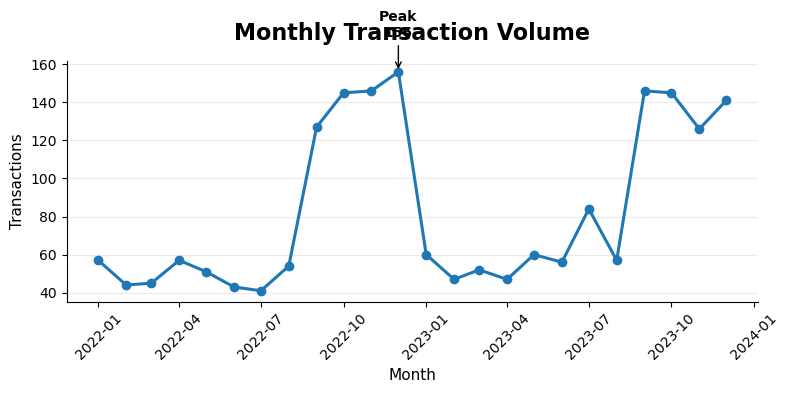

In [363]:
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(
    monthly_transactions["year_month"],
    monthly_transactions["transactions"],
    marker="o",
    linewidth=2.2
)

# Annotate highest transaction month
peak_transaction_month = (
    monthly_transactions
    .sort_values("transactions", ascending=False)
    .iloc[0]
)

ax.annotate(
    f"Peak\n{peak_transaction_month['transactions']:,}",
    xy=(
        peak_transaction_month["year_month"],
        peak_transaction_month["transactions"]
    ),
    xytext=(0, 25),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    fontweight="bold",
    arrowprops={"arrowstyle": "->"}
)

ax.set_title(
    "Monthly Transaction Volume",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Month",
    fontsize=11
)

ax.set_ylabel(
    "Transactions",
    fontsize=11
)

ax.tick_params(
    axis="x",
    rotation=45
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [364]:
# MONTHLY TRANSACTION
monthly_driver_analysis = monthly_growth[
    [
        "year_month",
        "revenue",
        "revenue_change",
        "revenue_growth_pct"
    ]
].copy()

monthly_driver_analysis["transactions"] = (
    monthly_transactions["transactions"]
)

monthly_driver_analysis["transaction_growth_pct"] = (
    monthly_transactions["transaction_growth_pct"]
)

monthly_driver_analysis["aov"] = (
    monthly_transactions["aov"]
)
display(monthly_driver_analysis.head())

,year_month,revenue,revenue_change,revenue_growth_pct,transactions,transaction_growth_pct,aov
0,2022-01-01,22635.0,NaN,NaN,57,NaN,397.105263
1,2022-02-01,16110.0,-6525.0,-0.288270,44,-0.228070,366.136364
2,2022-03-01,23455.0,7345.0,0.455928,45,0.022727,521.222222
3,2022-04-01,28535.0,5080.0,0.216585,57,0.266667,500.614035
4,2022-05-01,24480.0,-4055.0,-0.142106,51,-0.105263,480.000000


#### Business Interpretation

Monthly transaction analysis measures changes in purchasing activity
over time.


### INSIGHT 15 Customer Age Distribution
What does the customer age profile look like, and which age groups represent the largest customer segments


In [365]:
# Age Segementation
# 18–24
# 25–34
# 35–44
# 45–54
# 55–64
# 65+
age_bins = [0, 24, 34, 44, 54, 64, np.inf]

age_labels = [
    "18–24",
    "25–34",
    "35–44",
    "45–54",
    "55–64",
    "65+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    right=True
)

In [366]:
# Customer-level age distribution
### KEEPING ONE RECORD FOR PERSON WITH 2 OR MORE TRANSACTION
customer_age = (
    df[["customer_id", "age", "age_group"]]
    .drop_duplicates("customer_id")
    .dropna(subset=["age_group"])
)
# NOW DISTRIBUTION
age_distribution = (
    customer_age
    .groupby("age_group", observed=True)
    .agg(
        customers=("customer_id", "nunique")
    )
    .reset_index()
)
age_distribution
age_distribution["customer_share"] = (
    age_distribution["customers"] /
    age_distribution["customers"].sum()
)*100
display(age_distribution)

,age_group,customers,customer_share
0,18–24,28,18.064516
1,25–34,32,20.645161
2,35–44,27,17.419355
3,45–54,46,29.677419
4,55–64,22,14.193548


In [367]:
# LARGEST SEGMENT
largest_age_segment = (
    age_distribution
    .sort_values("customers", ascending=False)
    .iloc[0]
)

print(
    f"Largest Age Segment: "
    f"{largest_age_segment['age_group']}"
)
# SMALLEST SEGMENT
smallest_age_segment = (
    age_distribution
    .sort_values("customers")
    .iloc[0]
)

print(
    f"Smallest Age Segment: "
    f"{smallest_age_segment['age_group']}"
)



Largest Age Segment: 45–54
Smallest Age Segment: 55–64


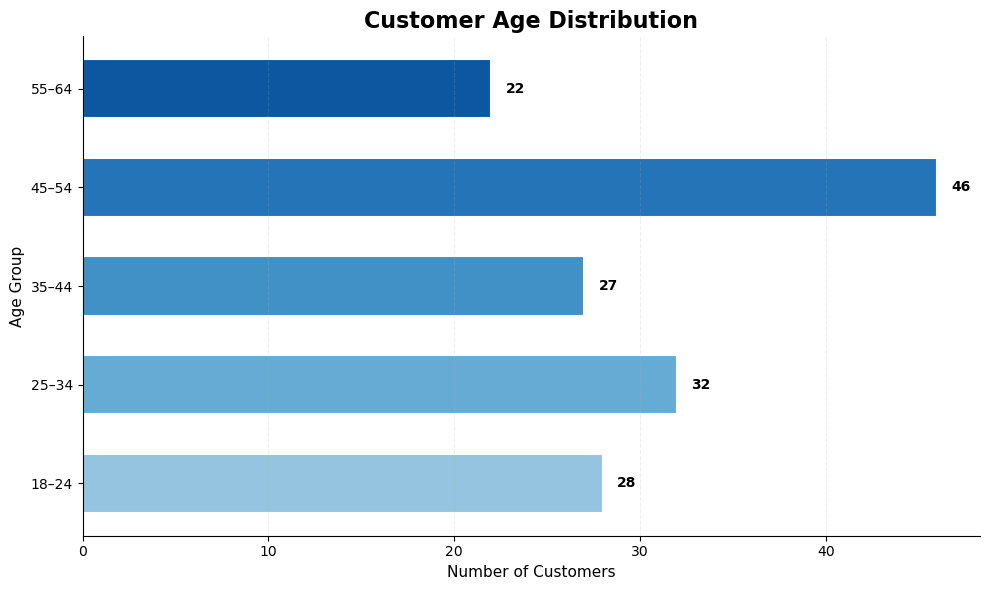

In [368]:
fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bars
bars = ax.barh(
    age_distribution["age_group"],
    age_distribution["customers"],
    color=plt.cm.Blues(np.linspace(0.4, 0.85, len(age_distribution))),
    height=0.6,
    edgecolor='white',
    linewidth=1.5
)

# Labels on bars
for bar, value in zip(bars, age_distribution["customers"]):
    ax.text(
        bar.get_width() + (total * 0.005),
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title("Customer Age Distribution", fontsize=16, fontweight="bold")
ax.set_xlabel("Number of Customers", fontsize=11)
ax.set_ylabel("Age Group", fontsize=11)

# Format x-axis
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Grid
ax.grid(axis="x", alpha=0.2, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

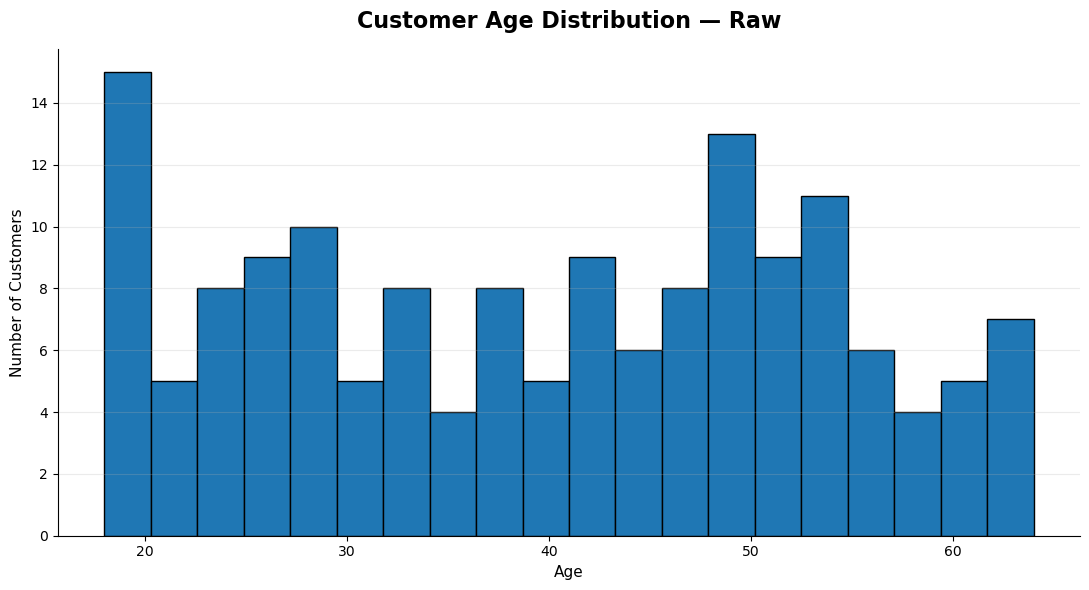

In [369]:
# HISTOGRAM FOR UNDERLYING AGE DISTRIBUTION
fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    customer_age["age"],
    bins=20,
    edgecolor="black"
)

ax.set_title(
    "Customer Age Distribution — Raw",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Age",
    fontsize=11
)

ax.set_ylabel(
    "Number of Customers",
    fontsize=11
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [370]:
# AGE GROUP REVENUE
age_business = (
    df.groupby("age_group", observed=True)
      .agg(
          revenue=("revenue", "sum"),
          transactions=("transactions_id", "nunique"),
          units_sold=("quantity", "sum"),
          gross_profit=("gross_profit", "sum")
      )
      .reset_index()
)
age_business["aov"] = (
    age_business["revenue"] /
    age_business["transactions"]
)
age_business["revenue_share"] = (
    age_business["revenue"] /
    total_revenue
)
display(age_business)

,age_group,revenue,transactions,units_sold,gross_profit,aov,revenue_share
0,18–24,149160.0,296,727.0,121151.05,503.918919,0.164232
1,25–34,194090.0,405,1041.0,149924.70,479.234568,0.213701
2,35–44,193595.0,413,1063.0,156867.05,468.753027,0.213156
3,45–54,193395.0,447,1151.0,154991.65,432.651007,0.212936
4,55–64,177990.0,426,1013.0,136367.75,417.816901,0.195975


In [371]:
highest_revenue_age = (
    age_business
    .sort_values("revenue", ascending=False)
    .iloc[0]
)

print(
    f"Highest Revenue Age Group: "
    f"{highest_revenue_age['age_group']}"
)
highest_revenue_age = (
    age_business
    .sort_values("revenue", ascending=False)
    .iloc[0]
)


Highest Revenue Age Group: 25–34


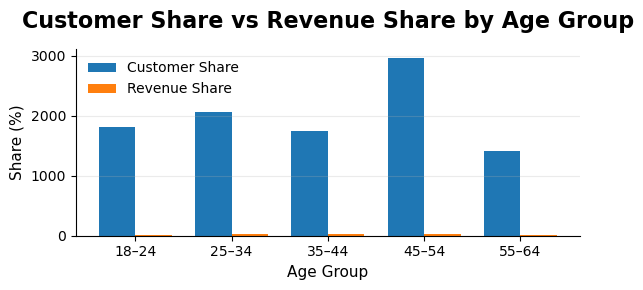

In [372]:
age_business["revenue_vs_customer_share"] = (
    age_business["revenue_share"]
    -
    (
        age_business["age_group"]
        .map(
            age_distribution
            .set_index("age_group")["customer_share"]
        )
    )
)
plot_age = age_business.copy()

x = np.arange(len(plot_age))
width = 0.38

fig, ax = plt.subplots(figsize=(6, 3))

ax.bar(
    x - width / 2,
    [
        age_distribution
        .set_index("age_group")
        .loc[group, "customer_share"] * 100
        for group in plot_age["age_group"]
    ],
    width,
    label="Customer Share"
)

ax.bar(
    x + width / 2,
    plot_age["revenue_share"] * 100,
    width,
    label="Revenue Share"
)

ax.set_title(
    "Customer Share vs Revenue Share by Age Group",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Age Group",
    fontsize=11
)

ax.set_ylabel(
    "Share (%)",
    fontsize=11
)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_age["age_group"].astype(str)
)

ax.legend(
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [373]:
age_insight = age_business[
    [
        "age_group",
        "revenue",
        "revenue_share",
        "transactions",
        "units_sold",
        "aov",
        "revenue_vs_customer_share"
    ]
].copy()

display(age_insight)

,age_group,revenue,revenue_share,transactions,units_sold,aov,revenue_vs_customer_share
0,18–24,149160.0,0.164232,296,727.0,503.918919,-17.900285
1,25–34,194090.0,0.213701,405,1041.0,479.234568,-20.431460
2,35–44,193595.0,0.213156,413,1063.0,468.753027,-17.206198
3,45–54,193395.0,0.212936,447,1151.0,432.651007,-29.464483
4,55–64,177990.0,0.195975,426,1013.0,417.816901,-13.997574


#### Business Interpretation

Customer age distribution identifies the demographic composition of
the customer base and highlights the largest customer segments.

Age-group revenue analysis goes beyond customer counts by measuring
the economic contribution of each segment.


### INSIGHT 16 Gender Distribution And Economic Contribution
Customer composition — who makes up the customer base?
Economic contribution — who generates the revenue and profit?


In [374]:
# Unique Customer
customer_gender = (
    df[["customer_id", "gender"]]
    .drop_duplicates("customer_id")
)
gender_distribution = (
    customer_gender
    .groupby("gender")
    .agg(
        customers=("customer_id", "nunique")
    )
    .reset_index()
)
gender_distribution

,gender,customers
0,Female,79
1,Male,76


In [375]:
gender_distribution["customer_share"] = (
    gender_distribution["customers"] /
    gender_distribution["customers"].sum()*100
)

display(gender_distribution)

,gender,customers,customer_share
0,Female,79,50.967742
1,Male,76,49.032258


In [376]:
# CUSTOMER AS FEMALE IS > CUSTOMER AS MALE

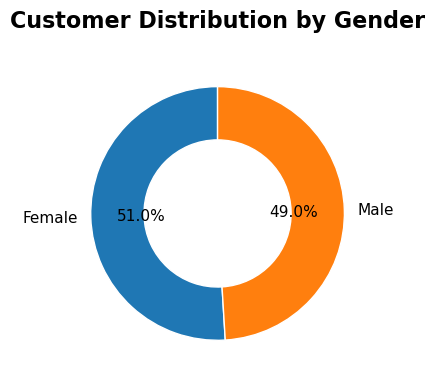

In [377]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.pie(
    gender_distribution["customers"],
    labels=gender_distribution["gender"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={
        "width": 0.42,
        "edgecolor": "white"
    },
    textprops={
        "fontsize": 11
    }
)

ax.set_title(
    "Customer Distribution by Gender",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

In [378]:
# REVENUE BY EACH GENDER
gender_business=df.groupby('gender').agg(
    revenue=('revenue','sum'),
     transactions=("transactions_id", "nunique"),
          units_sold=("quantity", "sum"),
          gross_profit=("gross_profit", "sum")
).reset_index()
gender_business

,gender,revenue,transactions,units_sold,gross_profit
0,Female,463110.0,1012,2573.0,360221.75
1,Male,445120.0,975,2422.0,359080.45


In [379]:
# ALL FINANCIAL METRICS
gender_business["revenue_share"] = (
    gender_business["revenue"] /
    total_revenue
)

gender_business["aov"] = (
    gender_business["revenue"] /
    gender_business["transactions"]
)

gender_business["gross_margin_pct"] = (
    gender_business["gross_profit"] /
    gender_business["revenue"]
)

gender_business["gross_pp_transaction"] = (
    gender_business["gross_profit"] /
    gender_business["transactions"]
)
display(gender_business)

,gender,revenue,transactions,units_sold,gross_profit,revenue_share,aov,gross_margin_pct,gross_pp_transaction
0,Female,463110.0,1012,2573.0,360221.75,0.509904,457.618577,0.777832,355.950346
1,Male,445120.0,975,2422.0,359080.45,0.490096,456.533333,0.806705,368.287641


In [380]:
display(
    gender_business[
        [
            "gender",
            "revenue",
            "revenue_share",
            "aov",
            "gross_profit",
            "gross_margin_pct",
        ]
    ]
)

,gender,revenue,revenue_share,aov,gross_profit,gross_margin_pct
0,Female,463110.0,0.509904,457.618577,360221.75,0.777832
1,Male,445120.0,0.490096,456.533333,359080.45,0.806705


#### BUSINESS INSIGHT
Female customers contribute a larger share of revenue than their share of the customer base.

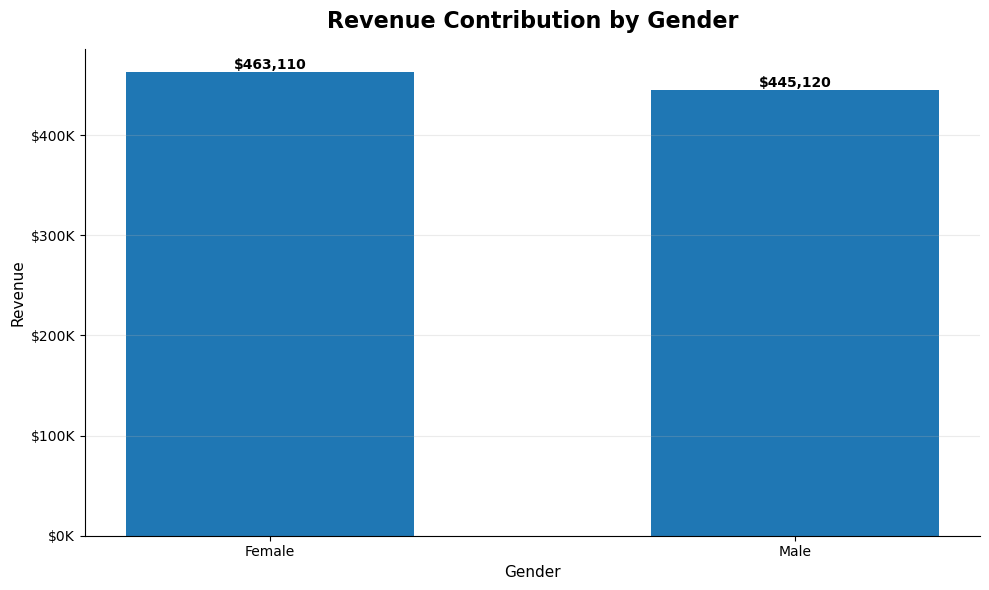

In [381]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    gender_business["gender"],
    gender_business["revenue"],
    width=0.55
)

for bar, value in zip(
    bars,
    gender_business["revenue"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Revenue Contribution by Gender",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Gender",
    fontsize=11
)

ax.set_ylabel(
    "Revenue",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"${x/1000:.0f}K"
    )
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### INSIGHT 17 Age × Category Analysis
product categories are most important to each age group, and which age × category combinations generate the most revenue and profit

In [382]:
age_category_revenue = (
    df.groupby(
        ["age_group", "category"],
        observed=True
    )["revenue"]
    .sum()
    .unstack(fill_value=0)
)

display(age_category_revenue)

category,Beauty,Clothing,Electronics
age_group,,,
18–24,57670.0,44320.0,47170.0
25–34,57080.0,83190.0,53820.0
35–44,58900.0,61775.0,72920.0
45–54,71900.0,58090.0,63405.0
55–64,41240.0,62620.0,74130.0


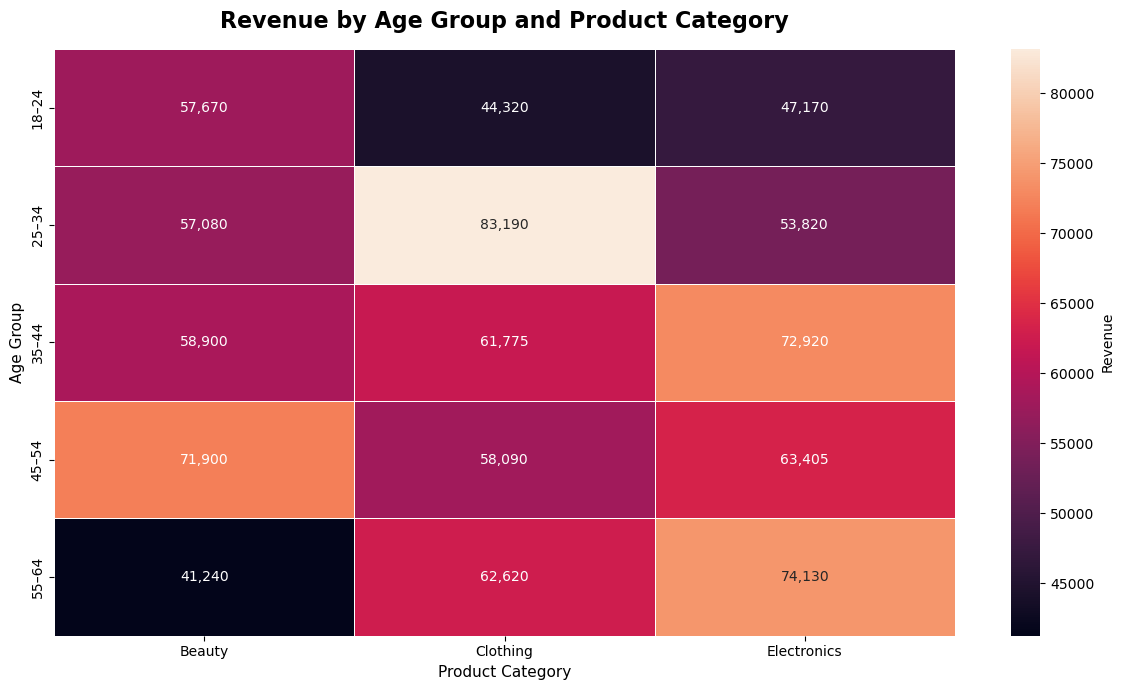

In [383]:
# HEATMAP-- Darker/larger cells indicate higher revenue.
fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(
    age_category_revenue,
    annot=True,
    fmt=",.0f",
    linewidths=0.5,
    cbar_kws={"label": "Revenue"},
    ax=ax
)

ax.set_title(
    "Revenue by Age Group and Product Category",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Product Category",
    fontsize=11
)

ax.set_ylabel(
    "Age Group",
    fontsize=11
)

plt.tight_layout()
plt.show()

In [384]:
age_category_table = (
    df.groupby(
        ["age_group", "category"],
        observed=True
    )
    .agg(
        revenue=("revenue", "sum"),
        transactions=("transactions_id", "nunique"),
        units_sold=("quantity", "sum"),
        gross_profit=("gross_profit", "sum")
    )
    .reset_index()
)
display(age_category_table.head())

,age_group,category,revenue,transactions,units_sold,gross_profit
0,18–24,Beauty,57670.0,104,267.0,47142.85
1,18–24,Clothing,44320.0,90,224.0,37089.15
2,18–24,Electronics,47170.0,102,236.0,36919.05
3,25–34,Beauty,57080.0,136,354.0,45277.40
4,25–34,Clothing,83190.0,145,363.0,65505.35


In [385]:
# Financial Metrics
age_category_table["gross_margin_pct"] = (
    age_category_table["gross_profit"]
    /
    age_category_table["revenue"]
)
age_category_table["aov"] = (
    age_category_table["revenue"]
    /
    age_category_table["transactions"]
)
top_age_category = (
    age_category_table
    .sort_values("revenue", ascending=False)
    .iloc[0]
)

print(
    f"Top Age × Category Combination: "
    f"{top_age_category['age_group']} × "
    f"{top_age_category['category']}"
)

Top Age × Category Combination: 25–34 × Clothing


In [386]:
age_category_table["age_group_revenue_share"] = (
    age_category_table["revenue"]
    /
    age_category_table
    .groupby("age_group", observed=True)["revenue"]
    .transform("sum")
)
display(
    age_category_table[
        [
            "age_group",
            "category",
            "revenue",
            "age_group_revenue_share"
        ]
    ]
    .sort_values(
        ["age_group", "revenue"],
        ascending=[True, False]
    )
)

,age_group,category,revenue,age_group_revenue_share
0,18–24,Beauty,57670.0,0.386632
2,18–24,Electronics,47170.0,0.316238
1,18–24,Clothing,44320.0,0.297131
4,25–34,Clothing,83190.0,0.428616
3,25–34,Beauty,57080.0,0.294090
5,25–34,Electronics,53820.0,0.277294
8,35–44,Electronics,72920.0,0.376663
7,35–44,Clothing,61775.0,0.319094
6,35–44,Beauty,58900.0,0.304243
9,45–54,Beauty,71900.0,0.371778


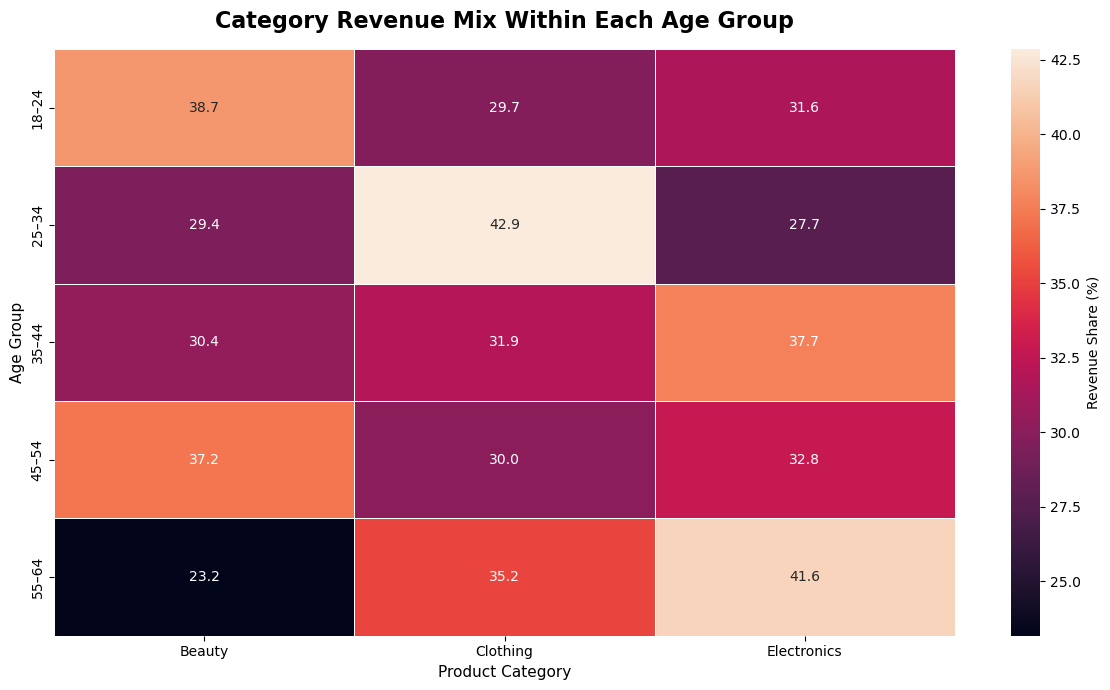

In [387]:
# REVENUE SHARE BY EACH AGE GROUP BY CATEGORY
age_category_mix = (
    age_category_table
    .pivot(
        index="age_group",
        columns="category",
        values="age_group_revenue_share"
    )
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(
    age_category_mix * 100,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={"label": "Revenue Share (%)"},
    ax=ax
)

ax.set_title(
    "Category Revenue Mix Within Each Age Group",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Product Category",
    fontsize=11
)

ax.set_ylabel(
    "Age Group",
    fontsize=11
)

plt.tight_layout()
plt.show()

In [388]:
age_category_insight = age_category_table[
    [
        "age_group",
        "category",
        "revenue",
        "age_group_revenue_share",
        "transactions",
        "units_sold",
        "aov",
        "gross_profit",
        "gross_margin_pct"
    ]
].copy()

display(age_category_insight)

,age_group,category,revenue,age_group_revenue_share,transactions,units_sold,aov,gross_profit,gross_margin_pct
0,18–24,Beauty,57670.0,0.386632,104,267.0,554.519231,47142.85,0.817459
1,18–24,Clothing,44320.0,0.297131,90,224.0,492.444444,37089.15,0.836849
2,18–24,Electronics,47170.0,0.316238,102,236.0,462.450980,36919.05,0.782681
3,25–34,Beauty,57080.0,0.294090,136,354.0,419.705882,45277.40,0.793227
4,25–34,Clothing,83190.0,0.428616,145,363.0,573.724138,65505.35,0.787419
5,25–34,Electronics,53820.0,0.277294,124,324.0,434.032258,39141.95,0.727275
6,35–44,Beauty,58900.0,0.304243,102,258.0,577.450980,47240.05,0.802038
7,35–44,Clothing,61775.0,0.319094,157,429.0,393.471338,49755.20,0.805426
8,35–44,Electronics,72920.0,0.376663,154,376.0,473.506494,59871.80,0.821061
9,45–54,Beauty,71900.0,0.371778,146,372.0,492.465753,57825.70,0.804252


#### Business Interpretation

Age × category analysis identifies differences in product-category
performance across customer age segments.

Absolute revenue highlights the largest revenue-generating
age-category combinations, while within-age-group revenue share
reveals the spending composition of each demographic segment.

### INSIGHT 18 AGE DISTRIBUTION X CATEGORY ANALYSIS
categories drive revenue for each gender, and are there meaningful differences in category mix, AOV, and profitability


In [389]:
gender_category = (
    df.groupby(["gender", "category"])
      .agg(
          revenue=("revenue", "sum"),
          transactions=("transactions_id", "nunique"),
          units_sold=("quantity", "sum"),
          gross_profit=("gross_profit", "sum")
      )
      .reset_index()
)

gender_category["aov"] = (
    gender_category["revenue"] /
    gender_category["transactions"]
)

gender_category["gross_margin_pct"] = (
    gender_category["gross_profit"] /
    gender_category["revenue"]
)

display(gender_category)

,gender,category,revenue,transactions,units_sold,gross_profit,aov,gross_margin_pct
0,Female,Beauty,149470.0,330,829.0,116837.90,452.939394,0.781681
1,Female,Clothing,162460.0,347,879.0,126300.35,468.184438,0.777424
2,Female,Electronics,151180.0,335,865.0,117083.50,451.283582,0.774464
3,Male,Beauty,137320.0,281,704.0,111751.50,488.683274,0.813804
4,Male,Clothing,147535.0,351,901.0,119644.90,420.327635,0.810959
5,Male,Electronics,160265.0,343,817.0,127684.05,467.244898,0.796706


In [390]:
gender_category["gender_revenue_share"] = (gender_category["revenue"]
    /
    gender_category
    .groupby("gender")["revenue"]
    .transform("sum")
)
display(gender_category[
        [
            "gender",
            "category",
            "revenue",
            "gender_revenue_share",
            "transactions",
            "aov",
            "gross_profit",
            "gross_margin_pct"
        ]
    ]
)

,gender,category,revenue,gender_revenue_share,transactions,aov,gross_profit,gross_margin_pct
0,Female,Beauty,149470.0,0.322753,330,452.939394,116837.90,0.781681
1,Female,Clothing,162460.0,0.350802,347,468.184438,126300.35,0.777424
2,Female,Electronics,151180.0,0.326445,335,451.283582,117083.50,0.774464
3,Male,Beauty,137320.0,0.308501,281,488.683274,111751.50,0.813804
4,Male,Clothing,147535.0,0.331450,351,420.327635,119644.90,0.810959
5,Male,Electronics,160265.0,0.360049,343,467.244898,127684.05,0.796706


In [391]:
top_category_by_gender = (
    gender_category
    .sort_values(
        ["gender", "revenue"],
        ascending=[True, False]
    )
    .groupby("gender")
    .first()
    .reset_index()
)

display(
    top_category_by_gender[
        [
            "gender",
            "category",
            "revenue",
            "gender_revenue_share",
            "aov",
            "gross_profit",
            "gross_margin_pct"
        ]
    ]
)

,gender,category,revenue,gender_revenue_share,aov,gross_profit,gross_margin_pct
0,Female,Clothing,162460.0,0.350802,468.184438,126300.35,0.777424
1,Male,Electronics,160265.0,0.360049,467.244898,127684.05,0.796706


In [392]:
# REVENUE GENERATED BY GENDER
gender_category_revenue = (
    gender_category
    .pivot(
        index="gender",
        columns="category",
        values="revenue"
    )
    .fillna(0)
)

display(gender_category_revenue)

category,Beauty,Clothing,Electronics
gender,,,
Female,149470.0,162460.0,151180.0
Male,137320.0,147535.0,160265.0


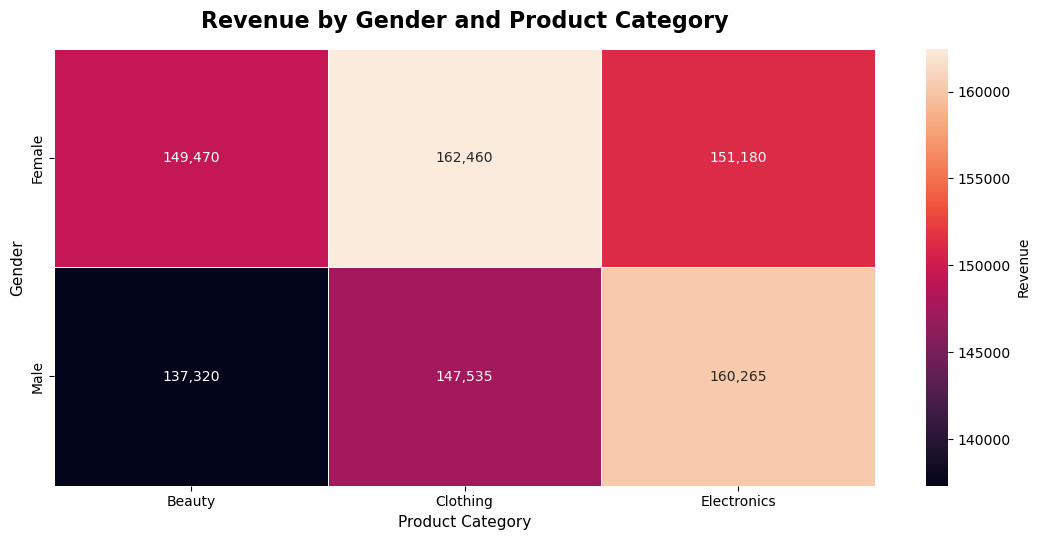

In [393]:
fig, ax = plt.subplots(figsize=(11, 5.5))

sns.heatmap(
    gender_category_revenue,
    annot=True,
    fmt=",.0f",
    linewidths=0.5,
    cbar_kws={"label": "Revenue"},
    ax=ax
)

ax.set_title(
    "Revenue by Gender and Product Category",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Product Category",
    fontsize=11
)

ax.set_ylabel(
    "Gender",
    fontsize=11
)

plt.tight_layout()
plt.show()

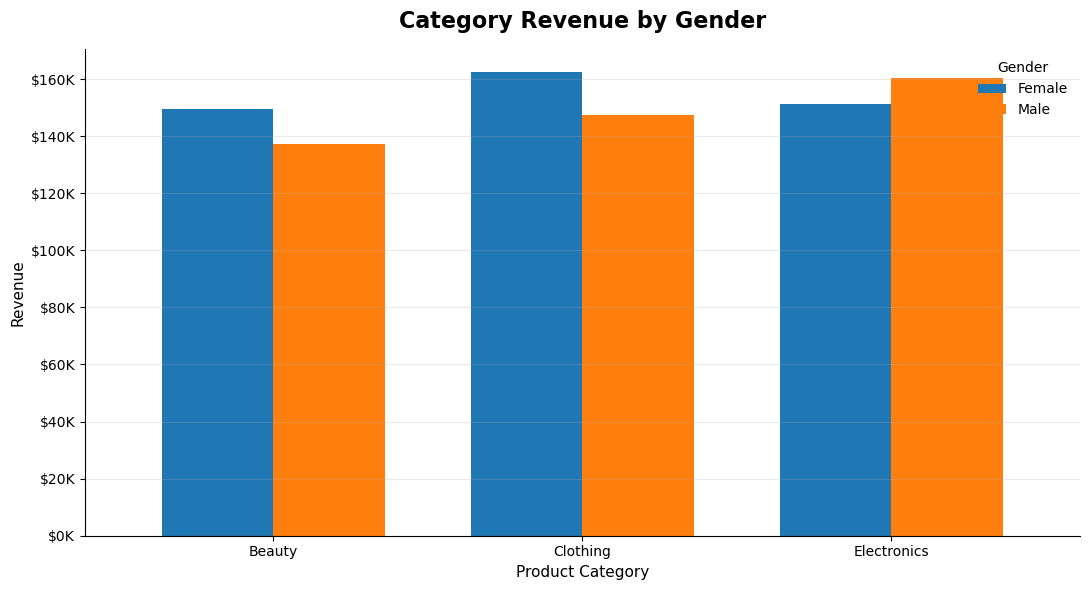

In [394]:
# COMPARISON CHART
plot_gender_category = gender_category.pivot(
    index="category",
    columns="gender",
    values="revenue"
)

fig, ax = plt.subplots(figsize=(11, 6))

plot_gender_category.plot(
    kind="bar",
    ax=ax,
    width=0.72
)

ax.set_title(
    "Category Revenue by Gender",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Product Category",
    fontsize=11
)

ax.set_ylabel(
    "Revenue",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"${x/1000:.0f}K"
    )
)

ax.tick_params(
    axis="x",
    rotation=0
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Gender",
    frameon=False
)

plt.tight_layout()
plt.show()

### Business Interpretation
FEMALE GENERALLY SPENDS MORE ON CLOTHING WHILE MALE SPENDS MORE ON ELECTRONICS
** Gender × category analysis identifies differences in product-category
performance across gender segments.

### INSIGHT 19 DAY-OF-WEEK-PERFOMANCE
Which days generate the most revenue, transactions, units, and profit, and are high-revenue days actually more valuable per transaction

In [395]:
df["day_of_week"] = df["sale_date"].dt.day_name()
day_performance = (
    df.groupby("day_of_week", observed=True)
      .agg(
          revenue=("revenue", "sum"),
          transactions=("transactions_id", "nunique"),
          units_sold=("quantity", "sum"),
          gross_profit=("gross_profit", "sum"),
          customers=("customer_id", "nunique")
      )
      .reset_index()
)

In [396]:
#FINANCIAL MATRIX
day_performance["aov"] = (
    day_performance["revenue"] /
    day_performance["transactions"]
)

day_performance["gross_margin_pct"] = (
    day_performance["gross_profit"] /
    day_performance["revenue"]
)

day_performance["revenue_share"] = (
    day_performance["revenue"] /
    total_revenue
)

day_performance["units_per_transaction"] = (
    day_performance["units_sold"] /
    day_performance["transactions"]
)
display(day_performance)

,day_of_week,revenue,transactions,units_sold,gross_profit,customers,aov,gross_margin_pct,revenue_share,units_per_transaction
0,Friday,120605.0,287,722.0,95587.15,118,420.226481,0.792564,0.132791,2.515679
1,Monday,147575.0,278,720.0,118065.00,111,530.845324,0.800034,0.162486,2.589928
2,Saturday,141400.0,309,783.0,109291.35,122,457.605178,0.772923,0.155687,2.533981
3,Sunday,152800.0,311,803.0,120252.10,119,491.318328,0.786990,0.168239,2.581994
4,Thursday,122585.0,286,691.0,98543.45,120,428.618881,0.803879,0.134971,2.416084
5,Tuesday,102845.0,244,614.0,82785.70,108,421.495902,0.804956,0.113237,2.516393
6,Wednesday,120420.0,272,662.0,94777.45,113,442.720588,0.787057,0.132588,2.433824


In [397]:
# BEST REVENUE DAY AND WORST REVENUE DAY
best_revenue_day = (
    day_performance
    .sort_values("revenue", ascending=False)
    .iloc[0]
)

worst_revenue_day = (
    day_performance
    .sort_values("revenue")
    .iloc[0]
)

print(
    f"Best Revenue Day: "
    f"{best_revenue_day['day_of_week']}"
)

print(
    f"Best Revenue Day: "
    f"{worst_revenue_day['day_of_week']}"
)


Best Revenue Day: Sunday
Best Revenue Day: Tuesday


In [398]:
# REVENUE GAP BETWEEN BEST AND WORST
day_revenue_gap = (
    best_revenue_day["revenue"]
    -
    worst_revenue_day["revenue"]
)

day_revenue_gap_pct = (
    day_revenue_gap /
    worst_revenue_day["revenue"]
)

print(
    f"Best vs Worst Day Revenue Gap: "
    f"{day_revenue_gap:,.2f}"
)
display(
    day_performance[
        [
            "day_of_week",
            "revenue",
            "revenue_share"
        ]
    ].sort_values('revenue',ascending=False).reset_index()
)


Best vs Worst Day Revenue Gap: 49,955.00


,index,day_of_week,revenue,revenue_share
0,3,Sunday,152800.0,0.168239
1,1,Monday,147575.0,0.162486
2,2,Saturday,141400.0,0.155687
3,4,Thursday,122585.0,0.134971
4,0,Friday,120605.0,0.132791
5,6,Wednesday,120420.0,0.132588
6,5,Tuesday,102845.0,0.113237


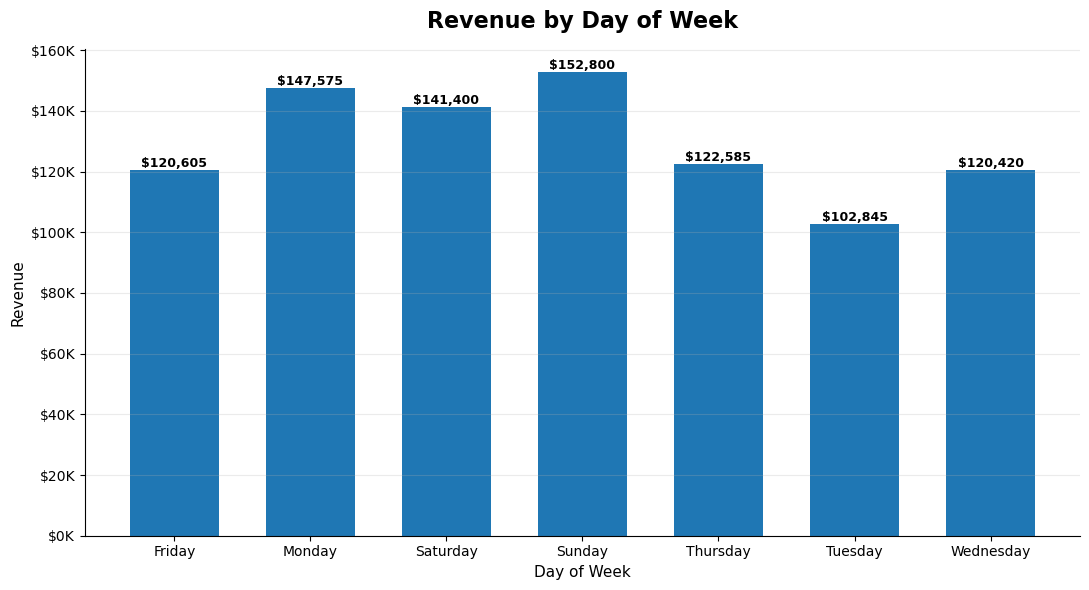

In [399]:
# VISUAL COMPARISON -- REVENUE WISE
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    day_performance["day_of_week"],
    day_performance["revenue"],
    width=0.65
)

for bar, value in zip(
    bars,
    day_performance["revenue"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

ax.set_title(
    "Revenue by Day of Week",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Day of Week",
    fontsize=11
)

ax.set_ylabel(
    "Revenue",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"${x/1000:.0f}K"
    )
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

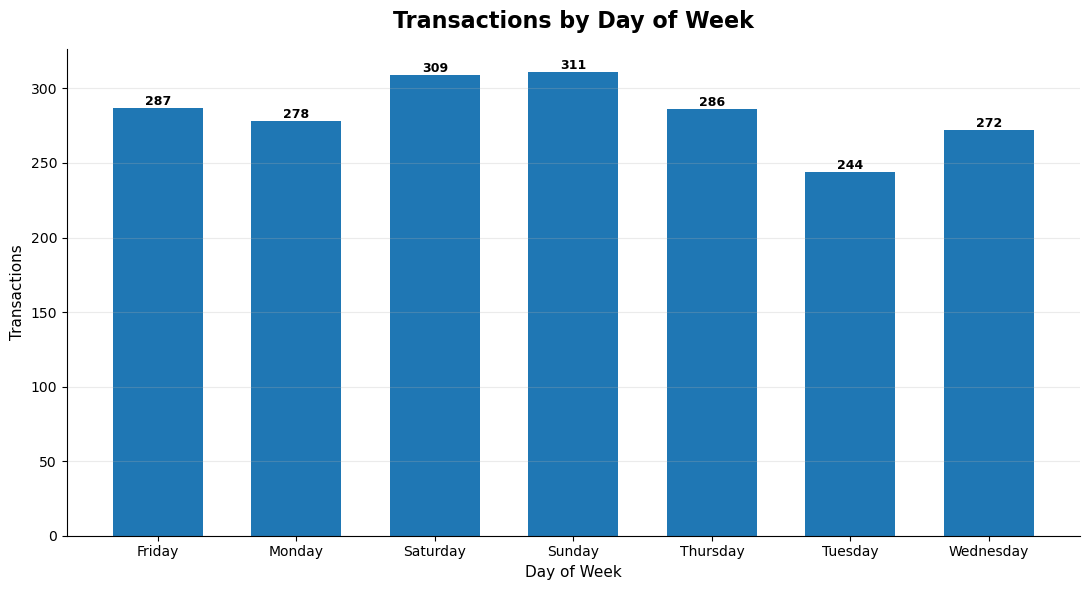

In [400]:
# VISUAL COMPARISON -- TRANSACTION WISE
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    day_performance["day_of_week"],
    day_performance["transactions"],
    width=0.65
)

for bar, value in zip(
    bars,
    day_performance["transactions"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

ax.set_title(
    "Transactions by Day of Week",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Day of Week",
    fontsize=11
)

ax.set_ylabel(
    "Transactions",
    fontsize=11
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#### Business Interpretation
##### SUNDAY IS THE BEST WEEK DAY
##### Tuesday IS THE Worst WEEK DAY
Day-of-week analysis identifies when customer purchasing activity
is concentrated throughout the week.


### INSIGHT 20 Monthly × Category Performance
categories drive revenue for each gender, and are there meaningful differences in category mix, AOV, and profitability


In [401]:
# FORMATTING DATE
df["sale_date"] = pd.to_datetime(df["sale_date"])
df["month_num"] = df["sale_date"].dt.month
df["month_name"] = df["sale_date"].dt.month_name()
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

df["month_name"] = pd.Categorical(
    df["month_name"],
    categories=month_order,
    ordered=True
)

In [402]:
# MONTHLY CATEGORY PERFOMANCE
monthly_category = (
    df.groupby(
        ["month_name", "category"],
        observed=True
    )
    .agg(
        revenue=("revenue", "sum"),
        transactions=("transactions_id", "nunique"),
        units_sold=("quantity", "sum"),
        gross_profit=("gross_profit", "sum")
    )
    .reset_index()
)
# FINANCIAL MATRIX
monthly_category["aov"] = (
    monthly_category["revenue"] /
    monthly_category["transactions"]
)

monthly_category["gross_margin_pct"] = (
    monthly_category["gross_profit"] /
    monthly_category["revenue"]
)

monthly_category["revenue_share"] = (
    monthly_category["revenue"] /
    total_revenue
)

In [403]:
display(monthly_category.head())

,month_name,category,revenue,transactions,units_sold,gross_profit,aov,gross_margin_pct,revenue_share
0,January,Beauty,12905.0,32,80.0,11110.50,403.281250,0.860945,0.014209
1,January,Clothing,20520.0,49,126.0,17366.45,418.775510,0.846318,0.022593
2,January,Electronics,13000.0,36,96.0,10967.60,361.111111,0.843662,0.014314
3,February,Beauty,16175.0,26,72.0,13561.05,622.115385,0.838396,0.017809
4,February,Clothing,11975.0,32,77.0,10154.95,374.218750,0.848013,0.013185


In [404]:
# REVENUE
monthly_category_revenue = (
    monthly_category
    .pivot(
        index="month_name",
        columns="category",
        values="revenue"
    )
    .fillna(0)
)

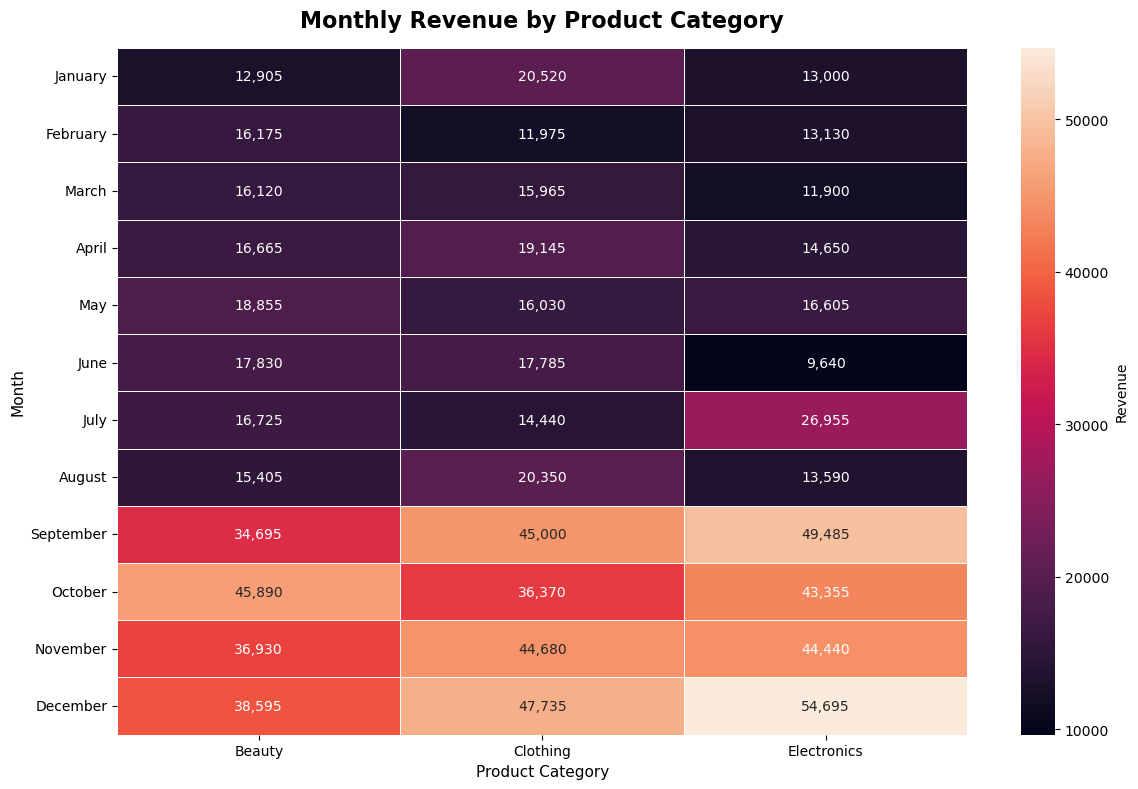

In [405]:
# HEATMAP-- DARKER AREA MORE REVENUE
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    monthly_category_revenue,
    annot=True,
    fmt=",.0f",
    linewidths=0.5,
    cbar_kws={"label": "Revenue"},
    ax=ax
)

ax.set_title(
    "Monthly Revenue by Product Category",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Product Category",
    fontsize=11
)

ax.set_ylabel(
    "Month",
    fontsize=11
)

plt.tight_layout()
plt.show()

In [406]:
# STRONG MONTH
top_month_category = (
    monthly_category
    .sort_values("revenue", ascending=False)
    .iloc[0]
)

print(
    f"Top Month × Category: "
    f"{top_month_category['month_name']} × "
    f"{top_month_category['category']}"
)


Top Month × Category: December × Electronics


In [407]:
monthly_category["monthly_category_share"] = (
    monthly_category["revenue"]
    /
    monthly_category
    .groupby("month_name", observed=True)["revenue"]
    .transform("sum")
)
display(
    monthly_category[
        [
            "month_name",
            "category",
            "revenue",
            "monthly_category_share"
        ]
    ].head()
)

,month_name,category,revenue,monthly_category_share
0,January,Beauty,12905.0,0.277975
1,January,Clothing,20520.0,0.442003
2,January,Electronics,13000.0,0.280022
3,February,Beauty,16175.0,0.391836
4,February,Clothing,11975.0,0.290092


In [408]:
# BEST CATEGORY FROM EACH MONTH
dominant_category_by_month = (
    monthly_category
    .sort_values(
        ["month_name", "monthly_category_share"],
        ascending=[True, False]
    )
    .groupby("month_name", observed=True)
    .first()
    .reset_index()
)
display(
    dominant_category_by_month[
        [
            "month_name",
            "category",
            "revenue",
            "monthly_category_share",
            "gross_profit",
            "gross_margin_pct"
        ]
    ]
)

,month_name,category,revenue,monthly_category_share,gross_profit,gross_margin_pct
0,January,Clothing,20520.0,0.442003,17366.45,0.846318
1,February,Beauty,16175.0,0.391836,13561.05,0.838396
2,March,Beauty,16120.0,0.366489,13686.70,0.849051
3,April,Clothing,19145.0,0.379409,15972.20,0.834275
4,May,Beauty,18855.0,0.366188,15933.45,0.845052
5,June,Beauty,17830.0,0.393990,14677.85,0.823211
6,July,Electronics,26955.0,0.463782,22659.20,0.840631
7,August,Clothing,20350.0,0.412402,17171.05,0.843786
8,September,Electronics,49485.0,0.383070,37092.10,0.749562
9,October,Beauty,45890.0,0.365323,33561.15,0.731339


In [409]:
# BEST MONTH FOR EACH CATEGORY
best_month_by_category = (
    monthly_category
    .sort_values(
        ["category", "revenue"],
        ascending=[True, False]
    )
    .groupby("category")
    .first()
    .reset_index()
)
display(
    best_month_by_category[
        [
            "category",
            "month_name",
            "revenue",
            "transactions",
            "aov",
            "gross_profit",
            "gross_margin_pct"
        ]
    ]
)

,category,month_name,revenue,transactions,aov,gross_profit,gross_margin_pct
0,Beauty,October,45890.0,95,483.052632,33561.15,0.731339
1,Clothing,December,47735.0,94,507.819149,36258.20,0.759573
2,Electronics,December,54695.0,108,506.435185,42997.65,0.786135


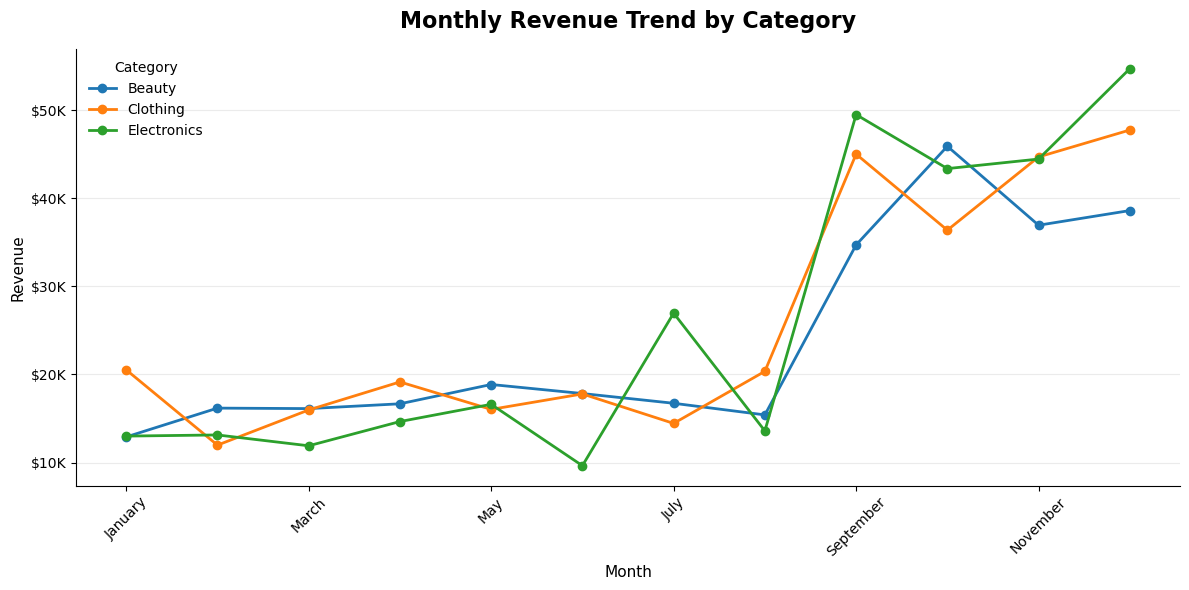

In [410]:
# CATEGORY TREND LINE CHART
category_month_plot = (
    monthly_category
    .pivot(
        index="month_name",
        columns="category",
        values="revenue"
    )
)

fig, ax = plt.subplots(figsize=(12, 6))

category_month_plot.plot(
    kind="line",
    marker="o",
    linewidth=2,
    ax=ax
)

ax.set_title(
    "Monthly Revenue Trend by Category",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Month",
    fontsize=11
)

ax.set_ylabel(
    "Revenue",
    fontsize=11
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"${x/1000:.0f}K"
    )
)

ax.tick_params(
    axis="x",
    rotation=45
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Category",
    frameon=False
)

plt.tight_layout()
plt.show()

#### Business Interpretation
###### BEST MONTH FOR BEAUTY CATEGORY IS OCTOBER REST DECEMBER
Monthly × category analysis evaluates how product-category
performance changes throughout the year.

Absolute revenue identifies the largest category-month
combinations, while monthly category share identifies changes in
the composition of sales over time.

### Customer Purchase Frequency
How frequently do customers purchase, and how much business comes from repeat customers


In [411]:
# UNIQUE CUSTOMERS
customer_frequency = (
    df.groupby("customer_id")
      .agg(
          transactions=("transactions_id", "nunique"),
          revenue=("revenue", "sum"),
          units_sold=("quantity", "sum"),
          gross_profit=("gross_profit", "sum")
      )
      .reset_index()
)
#FINANCIAL MATRIX
customer_frequency["aov"] = (
    customer_frequency["revenue"] /
    customer_frequency["transactions"]
)

customer_frequency["gross_margin_pct"] = (
    customer_frequency["gross_profit"] /
    customer_frequency["revenue"]
)
display(customer_frequency.head())

,customer_id,transactions,revenue,units_sold,gross_profit,aov,gross_margin_pct
0,1,76,30750.0,186.0,25754.35,404.605263,0.837540
1,2,69,25295.0,154.0,20474.75,366.594203,0.809439
2,3,76,38440.0,201.0,32860.85,505.789474,0.854861
3,4,73,23580.0,164.0,19446.95,323.013699,0.824722
4,5,63,30405.0,159.0,25583.35,482.619048,0.841419


In [412]:
frequency_distribution = (
    customer_frequency["transactions"]
    .value_counts()
    .sort_index()
    .reset_index()
)

frequency_distribution.columns = [
    "transactions",
    "customers"
]

display(frequency_distribution)

,transactions,customers
0,2,2
1,3,6
2,4,4
3,5,9
4,6,10
5,7,14
6,8,9
7,9,13
8,10,14
9,11,6


In [413]:
customer_frequency["customer_type"] = np.where(
    customer_frequency["transactions"] == 1,
    "One-Time",
    "Repeat"
)
customer_type_summary = (
    customer_frequency
    .groupby("customer_type")
    .agg(
        customers=("customer_id", "nunique"),
        revenue=("revenue", "sum"),
        transactions=("transactions", "sum"),
        gross_profit=("gross_profit", "sum")
    )
    .reset_index()
)
customer_type_summary["customer_share"] = (
    customer_type_summary["customers"] /
    customers
)

customer_type_summary["revenue_share"] = (
    customer_type_summary["revenue"] /
    total_revenue
)

customer_type_summary["transaction_share"] = (
    customer_type_summary["transactions"] /
    transaction
)

customer_type_summary["aov"] = (
    customer_type_summary["revenue"] /
    customer_type_summary["transactions"]
)

customer_type_summary["gross_margin_pct"] = (
    customer_type_summary["gross_profit"] /
    customer_type_summary["revenue"]
)

display(customer_type_summary)

,customer_type,customers,revenue,transactions,gross_profit,customer_share,revenue_share,transaction_share,aov,gross_margin_pct
0,Repeat,155,908230.0,1987,719302.2,1.0,1.0,1.0,457.086059,0.791982


In [414]:
# MOST FREQUENT CUSTOMER
top_frequency_customers = (
    customer_frequency
    .sort_values(
        ["transactions", "revenue"],
        ascending=[False, False]
    )
    .head(10)
)

display(top_frequency_customers.head(1))

,customer_id,transactions,revenue,units_sold,gross_profit,aov,gross_margin_pct,customer_type
2,3,76,38440.0,201.0,32860.85,505.789474,0.854861,Repeat


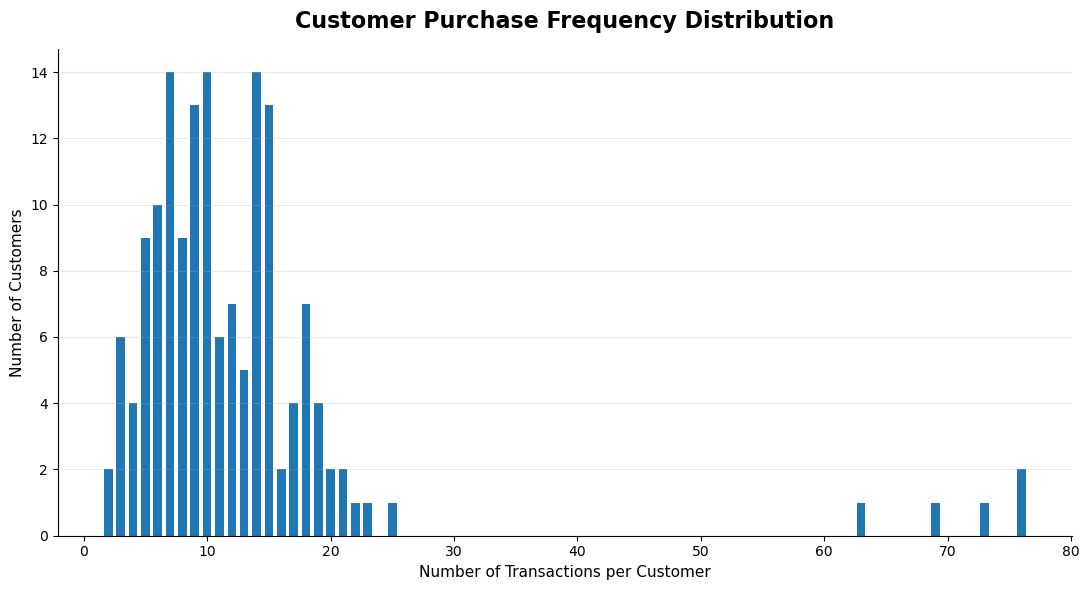

In [415]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    frequency_distribution["transactions"],
    frequency_distribution["customers"],
    width=0.7
)

ax.set_title(
    "Customer Purchase Frequency Distribution",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Number of Transactions per Customer",
    fontsize=11
)

ax.set_ylabel(
    "Number of Customers",
    fontsize=11
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

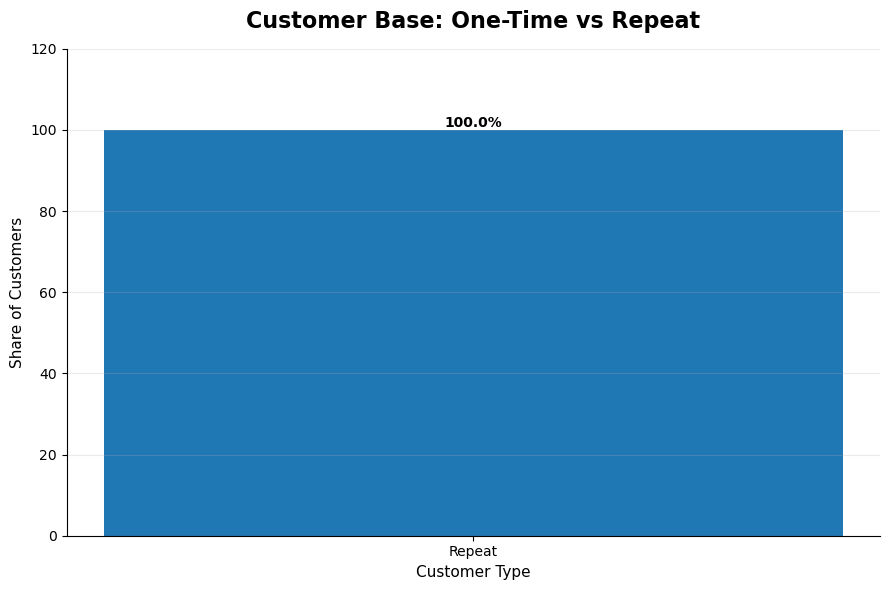

In [416]:
# ONE TIME VS REPEAT 
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    customer_type_summary["customer_type"],
    customer_type_summary["customer_share"] * 100,
    width=0.55
)

for bar, value in zip(
    bars,
    customer_type_summary["customer_share"] * 100
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Customer Base: One-Time vs Repeat",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Customer Type",
    fontsize=11
)

ax.set_ylabel(
    "Share of Customers",
    fontsize=11
)

ax.set_ylim(
    0,
    max(customer_type_summary["customer_share"] * 100) * 1.2
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# OVERALL INSIGHT

# 📊 RETAIL SALES ANALYSIS — EXECUTIVE SUMMARY

*Comprehensive Analysis of 1,987 Transactions | 2-Year Period (2022–2023) | 3 Product Categories | 155 Loyal Customers*

---

## 💰 FINANCIAL PERFORMANCE OVERVIEW

The business generated **$908,230** in total revenue across the 2-year analysis period, with strong profitability metrics indicating a healthy business model.

| Metric | Value | Insight |
|--------|-------|---------|
| **Total Revenue** | **$908,230** | Consistent revenue stream across 730 days |
| **Total Units Sold** | **4,995** | Steady sales volume |
| **Transactions** | **1,987** | Average of 2.7 transactions per day |
| **Average Order Value (AOV)** | **$457.09** | Customers spend nearly $460 per purchase |
| **Gross Profit** | **$719,302** | Strong profitability after COGS |
| **Gross Margin** | **79.2%** | Excellent margin — business keeps ~80¢ per $1 earned |
| **Units per Transaction** | **2.51** | Customers buy ~2.5 items per visit |

> **💡 What This Means:** The business is highly profitable with strong margins. Each customer transaction brings in nearly $460, and customers typically buy 2–3 items per visit.

---

## 📱 PRODUCT CATEGORY BREAKDOWN

All three categories perform strongly, but each has a distinct role in the business:

| Category | Revenue | Share | AOV | Units/Order | Gross Margin | Key Observation |
|----------|---------|-------|-----|-------------|--------------|-----------------|
| **Electronics** | **$311,445** | 34.3% | $459.36 | 2.48 | 78.6% | 🏆 **Highest Revenue** — drives 1/3 of all sales |
| **Clothing** | **$309,995** | 34.1% | $444.12 | **2.55** | 79.3% | 🛒 **Largest Basket** — customers buy the most items here |
| **Beauty** | **$286,790** | 31.6% | **$469.38** | 2.51 | **79.7%** | 💎 **Highest Value** — premium pricing & best margins |

### Category Insights:
- **Electronics** leads in total dollars — a revenue engine for the business
- **Clothing** drives volume — customers buy more items but at lower average value
- **Beauty** has the highest AOV and best margins — a profitability powerhouse

> **💡 What This Means:** While Electronics brings in the most money, Beauty is the most profitable per transaction. The business should consider:
> - Bundling Beauty products with Electronics purchases
> - Promoting higher-margin Beauty items during peak seasons
> - Leveraging Clothing's high volume for cross-selling opportunities

---

## 👥 CUSTOMER SEGMENT ANALYSIS

### By Age Group

| Age Group | Revenue | Customer Share | Revenue/ Customer | AOV | Top Category | Key Insight |
|-----------|---------|----------------|-------------------|-----|--------------|-------------|
| **18–24** | $149,160 (16.4%) | 18.1% | $5,327 | **$503.92** | Beauty | 💎 **Highest AOV** — young spenders buy premium |
| **25–34** | **$194,090 (21.4%)** | 20.6% | $6,065 | $479.23 | Clothing | 🏆 **Highest Revenue** — core customer segment |
| **35–44** | $193,595 (21.3%) | 17.4% | $7,170 | $468.75 | Electronics | 💪 **Highest Spend/Customer** — established buyers |
| **45–54** | $193,395 (21.3%) | **29.7%** | $4,204 | $432.65 | Beauty | 👥 **Largest Base** — most customers, lower avg spend |
| **55–64** | $177,990 (19.6%) | 14.2% | $8,090 | $417.82 | Electronics | 🎯 **High-Value Niche** — fewer but spend more |

### Key Customer Insights:

**📌 25–34 Year Olds (Young Adults)**
- Generate the most revenue (21.4% of total)
- Prefer Clothing (their #1 category)
- Above-average AOV ($479)
- **Opportunity:** Target with fashion marketing and loyalty programs

**📌 45–54 Year Olds (Middle-Aged)**
- Largest customer base (30% of all customers)
- Prefer Beauty products
- Lower average spend per customer
- **Opportunity:** Encourage more frequent purchases through targeted promotions

**📌 18–24 Year Olds (Gen Z)**
- Highest AOV ($504) — they spend BIG per transaction
- Prefer Beauty products
- Smallest segment by revenue
- **Opportunity:** Grow this segment with social media marketing and student discounts

### By Gender

| Gender | Share of Customers | Revenue Share | AOV | Top Category | Gross Margin | Insight |
|--------|-------------------|---------------|-----|--------------|--------------|---------|
| **Female** | 51% | **51.0%** | $457.62 | Clothing | 77.8% | 👩 **Slightly more valuable** — more customers, more revenue |
| **Male** | 49% | 49.0% | $456.53 | Electronics | **80.7%** | 👨 **More profitable** — higher margins on purchases |

### Gender Insights:
- **Female customers** prefer Clothing — this is their #1 category
- **Male customers** prefer Electronics — this drives their purchases
- Male purchases are more profitable (80.7% margin vs 77.8% for female)
- The customer base is nearly balanced (51% / 49%)

> **💡 What This Means:** 
> - Female customers drive more revenue; Male customers drive more profit
> - Marketing should be tailored: Clothing promotions for women, Electronics promotions for men
> - Consider gender-specific email campaigns and product recommendations

---

## 📅 TEMPORAL PATTERNS

### Best Day of Week: Sunday 🏆

| Day | Revenue | % of Weekly Revenue | Insight |
|-----|---------|---------------------|---------|
| **Sunday** | **$152,800** | 16.8% | 🥇 **Peak day** — customers shop most on weekends |
| Monday | $147,575 | 16.2% | Strong start to the work week |
| Saturday | $141,400 | 15.6% | Weekend shopping continues |
| Tuesday | **$102,845** | 11.3% | 🥉 **Weakest day** — 49% lower than Sunday |

**Sunday vs Tuesday Gap:** Sunday generates **$49,955 more** revenue than Tuesday — a **48.6% difference**.

> **💡 What This Means:** 
> - **Weekends (Sunday/Saturday)** + **Monday** are the best days — run promotions then
> - **Tuesday** is consistently weak — consider "Tuesday Specials" or targeted email campaigns
> - Staff scheduling should align with peak days

---

### Best Month: December 🎄

| Month | Revenue | Key Insight |
|-------|---------|-------------|
| **December** | **$71,880** | 🏆 **Peak month** — holiday shopping surge |
| November | $68,915 | Strong pre-holiday spending |
| October | $67,735 | Fall shopping momentum |
| **February** | **$16,110** | ❄️ **Weakest month** — post-holiday slump |

**December vs February Gap:** December generates **$55,770 more** — a **346% increase**.

### Monthly Growth Highlights:

| Best Growth Months | Worst Decline Months |
|--------------------|---------------------|
| September 2022: **+192%** | January 2023: **-66.9%** |
| September 2023: **+139%** | August 2023: **-21.3%** |
| March 2022: **+45.6%** | February 2022: **-28.8%** |

> **💡 What This Means:**
> - **September** shows massive growth (back-to-school/fall season) — invest in marketing
> - **January** has a dramatic drop (post-holiday) — plan retention campaigns
> - **Q4 (Oct–Dec)** is critical — ~30% of all revenue comes from these 3 months
> - **February** is consistently weak — consider Valentine's Day or winter sales events

---

## 🏷️ BEST SEGMENT × CATEGORY COMBINATIONS

These are the most powerful customer-category matches in the business:

| Rank | Segment × Category | Revenue | AOV | Gross Margin | Why It Matters |
|------|-------------------|---------|-----|--------------|----------------|
| 1 | **25–34 × Clothing** | **$83,190** | $573.72 | 78.7% | 🏆 **#1 Combo** — young adults love fashion, spend big |
| 2 | **55–64 × Electronics** | $74,130 | $518.39 | 78.0% | 📱 Mature customers invest in tech |
| 3 | **35–44 × Electronics** | $72,920 | $473.51 | 82.1% | 💼 Established buyers choose electronics |
| 4 | **45–54 × Beauty** | $71,900 | $492.47 | 80.4% | 💄 Middle-aged customers invest in beauty |
| 5 | **25–34 × Beauty** | $57,080 | $419.71 | 79.3% | 🌸 Young adults also love beauty |

### Category by Age Group — Revenue Share

| Age Group | #1 Category | #2 Category | #3 Category |
|-----------|-------------|-------------|-------------|
| **18–24** | Beauty (38.7%) | Electronics (31.6%) | Clothing (29.7%) |
| **25–34** | Clothing (42.9%) | Beauty (29.4%) | Electronics (27.7%) |
| **35–44** | Electronics (37.7%) | Clothing (31.9%) | Beauty (30.4%) |
| **45–54** | Beauty (37.2%) | Electronics (32.8%) | Clothing (30.0%) |
| **55–64** | Electronics (41.6%) | Clothing (35.2%) | Beauty (23.2%) |

> **💡 What This Means:**
> - **25–34 × Clothing** is the golden combination — focus marketing here
> - **Electronics** dominates for 35–44 and 55–64 age groups
> - **Beauty** is strong across all ages — a universal category
> - Each age group has a clear category preference — personalize marketing accordingly

---

## 👥 CUSTOMER LOYALTY & RETENTION

| Metric | Value | Insight |
|--------|-------|---------|
| **Total Customers** | 155 | Healthy customer base |
| **Repeat Customer Rate** | **100%** | 🔥 **All customers return** — exceptional loyalty! |
| **Avg Transactions per Customer** | 12.82 | Customers shop ~13 times over 2 years |
| **Avg Revenue per Customer** | $5,859.55 | Each customer worth ~$5,860 over 2 years |
| **Most Frequent Customer** | Customer #3 | 76 transactions, $38,440 spent |
| **Highest Spending Customer** | Customer #3 | $38,440 total spend |

### Customer Purchase Frequency Distribution

| Transactions | Customers | Observation |
|--------------|-----------|-------------|
| **10–20** | 14 customers each | Most common frequency bands |
| **76** | 2 customers | Ultra-loyal VIPs |
| **63–76** | 3 customers | Top 2% of customers drive significant revenue |

> **💡 What This Means:**
> - **100% repeat rate** is outstanding — customers love the brand
> - **Top customers** (like Customer #3) are extremely valuable — invest in VIP programs
> - The business has strong retention — focus on acquisition to grow further

---

## 🎯 STRATEGIC RECOMMENDATIONS

### 1. 🎯 Target High-Value Segments
- **25–34 × Clothing** is your best combo — increase marketing spend here
- **18–24** has the highest AOV — invest in social media/student marketing
- Create age-specific email campaigns with category recommendations

### 2. 📱 Leverage Top Categories
- **Electronics** drives revenue — ensure stock availability in Q4
- **Beauty** has highest margins — promote with cross-sell opportunities
- **Clothing** drives volume — use it for customer acquisition

### 3. 📅 Optimize Timing
- **Sunday** is peak — run weekend flash sales
- **Tuesday** is weak — launch "Tuesday Treats" promotions
- **Q4 (Sep–Dec)** is critical — increase ad spend, inventory, and staffing
- **January** needs retention campaigns to combat post-holiday drop

### 4. 👩 Target Female Customers
- Female customers drive 51% of revenue — focus on women's clothing/promotions
- Male customers are more profitable — maintain electronics offerings
- Balance gender-specific campaigns

### 5. 🤝 Invest in Loyalty
- 100% repeat rate is exceptional — launch a VIP/loyalty program
- Top customers (like Customer #3) deserve exclusive perks
- Use purchase history for personalized recommendations

---

## 📊 QUICK REFERENCE CARD

| What | Best | Worst | Gap |
|------|------|-------|-----|
| **Revenue** | $908,230 total | — | — |
| **AOV** | $457 average | — | — |
| **Day** | Sunday ($152,800) | Tuesday ($102,845) | +48.6% |
| **Month** | December ($71,880) | February ($16,110) | +346% |
| **Age Group** | 25–34 ($194,090) | 18–24 ($149,160) | +30% |
| **Gender** | Female (51%) | Male (49%) | Balanced |
| **Category** | Electronics ($311,445) | Beauty ($286,790) | +8.6% |
| **Top Combo** | 25–34 × Clothing ($83,190) | — | — |

---

*📊 Data Period: January 2022 – December 2023 | 1,987 Transactions | 155 Loyal Customers*

*Report generated from Retail Sales Dataset Analysis*